# 🚌 まちの「移動しにくい」を地図で見つけよう！
## 王寺町・神戸市垂水区　公共交通GIS × GTFS 演習

今日のゴールは、GISとGTFSを使って

> **「公共交通を改善するなら、どこから考える？」**

を見つけることです。

検討対象は、

- 🏘️ **奈良県王寺町**
- ⛰️ **神戸市垂水区**

です。

### 今日の5つのミッション

1. 👥 **未来の人口を読む**  
   子どもや75歳以上人口は、どこで・どう変わる？
2. 🚏 **坂を考えると、バス停はどれくらい遠く感じる？**  
   同じ500mでも、平地と坂道では歩く負担が違います。
3. 🎯 **「遠い × 人がいる」場所を探す**  
   公共交通の改善を考える候補を250mメッシュで抽出します。
4. 🕐 **GTFSで「いつ・どれだけ走るか」を見る**  
   路線別・時間帯別のサービス量を可視化します。
5. 💡 **改善アイデアをつくる**  
   停留所追加、経路変更、時間帯調整、DRTなどを考えます。

> GISやGTFSだけで改善策が決まるわけではありません。  
> まず**気になる場所を絞り込み**、その後に乗降実績・道路条件・収支などを確認する、という使い方を学びます。

## 1. 準備

最初に、GIS・グラフ・地図表示に必要なライブラリを準備します。

下のセルを1回実行してください。  
王寺町・垂水区の分析に必要なデータは、後のセルで自動的に読み込みます。

In [22]:
# @title ライブラリを準備
import importlib.util, subprocess, sys
required = {
    "geopandas": "geopandas",
    "pyogrio": "pyogrio",
    "folium": "folium",
    "japanize_matplotlib": "japanize-matplotlib",
    "requests": "requests",
}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("準備完了")

準備完了


In [23]:
# @title 共通処理（通常は開かなくて構いません）
from pathlib import Path
import io, math, re, shutil, zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import japanize_matplotlib
import folium
from IPython.display import display, Markdown
from branca.colormap import linear

BASE = (
    "https://github.com/HajimeSeya/"
    "toyooka-gtfs-gis-workshop/releases/download/workshop-2026"
)

YAMATOKORIYAMA_GTFS_URL = (
    "https://api.gtfs-data.jp/v2/organizations/"
    "yamatokoriyamacity/feeds/kingyobus/files/feed.zip?rid=current"
)

DATA_DIR = Path("workshop_data")
DATA_DIR.mkdir(exist_ok=True)

TARGETS = {
    "王寺町": {
        "asset": "oji_workshop_data.zip",
        "pref": "29",
        "shicode": "29425",
        "operator": "奈良交通",
        "label": "奈良県王寺町",
    },
    "垂水区": {
        "asset": "tarumi_workshop_data.zip",
        "pref": "28",
        "shicode": "28108",
        "operator": "山陽バス",
        "label": "神戸市垂水区",
    },
}

ROUTE_COLORS = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "cadetblue", "darkgreen", "pink", "gray"
]

def download(url, filename):
    """
    ファイルをダウンロードしてローカルに保存する。
    同じColabセッション内ですでに取得済みなら再利用する。
    """
    path = DATA_DIR / filename

    if path.exists() and path.stat().st_size > 100:
        return path

    print("download:", url)

    r = requests.get(
        url,
        timeout=240,
        allow_redirects=True,
        headers={"User-Agent": "Mozilla/5.0"},
    )

    try:
        r.raise_for_status()
    except requests.HTTPError as e:
        raise requests.HTTPError(
            f"データをダウンロードできませんでした "
            f"({r.status_code}): {url}"
        ) from e

    path.write_bytes(r.content)

    if path.stat().st_size <= 100:
        raise RuntimeError(
            f"ダウンロードしたファイルが小さすぎます: {filename}"
        )

    return path


def compact_asset_path(asset_name):
    """
    講習用データを取得する。
    同じColabセッションでは取得済みファイルを再利用する。
    """
    return download(
        f"{BASE}/{asset_name}",
        asset_name
    )


def read_compact_asset(asset_name):
    """
    講習用ZIPから人口・バス停・バスルートを読み込む。
    ZIP内部:
      population_slope.geojson
      stops.geojson
      routes.geojson
      metadata.json
    """
    zpath = compact_asset_path(asset_name)
    dest = DATA_DIR / Path(asset_name).stem

    if not dest.exists():
        dest.mkdir(parents=True, exist_ok=True)

    required = {
        "population_slope.geojson",
        "stops.geojson",
        "routes.geojson",
    }

    existing = {p.name for p in dest.glob("*")}

    if not required.issubset(existing):
        if dest.exists():
            shutil.rmtree(dest)
        dest.mkdir(parents=True)

        with zipfile.ZipFile(zpath) as zf:
            zf.extractall(dest)

    missing = [
        name for name in required
        if not (dest / name).exists()
    ]
    if missing:
        raise FileNotFoundError(
            "講習用ZIPに必要なファイルがありません: "
            + ", ".join(missing)
        )

    pop = ensure_wgs84(
        gpd.read_file(dest / "population_slope.geojson")
    )
    stops = ensure_wgs84(
        gpd.read_file(dest / "stops.geojson")
    )
    routes = ensure_wgs84(
        gpd.read_file(dest / "routes.geojson")
    )

    metadata = {}
    metadata_path = dest / "metadata.json"
    if metadata_path.exists():
        import json
        metadata = json.loads(
            metadata_path.read_text(encoding="utf-8")
        )

    return pop, stops, routes, metadata

def read_geojson_zip(url, key):
    zpath = download(url, key + ".zip")
    dest = DATA_DIR / key
    if dest.exists():
        shutil.rmtree(dest)
    dest.mkdir()
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall(dest)
    files = list(dest.rglob("*.geojson"))
    if not files:
        raise FileNotFoundError("GeoJSONが見つかりません: " + key)
    return gpd.read_file(files[0])

def ensure_wgs84(gdf, default_epsg=6668):
    g = gdf.copy()
    if g.crs is None:
        g = g.set_crs(epsg=default_epsg, allow_override=True)
    return g.to_crs(4326)

def clean_code(series, width=5):
    return (
        series.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
        .str.zfill(width)
    )

def deg_to_grade(deg):
    return 100.0 * math.tan(math.radians(float(deg)))

def gtfs_seconds(x):
    try:
        h, m, s = map(int, str(x).split(":"))
        return h * 3600 + m * 60 + s
    except Exception:
        return np.nan

def route_name_table(gtfs):
    routes = gtfs["routes"].copy()
    for c in ["route_short_name", "route_long_name"]:
        if c not in routes.columns:
            routes[c] = ""
        routes[c] = routes[c].fillna("").astype(str).str.strip()

    routes["路線名"] = routes["route_short_name"]
    routes.loc[routes["路線名"] == "", "路線名"] = routes["route_long_name"]
    routes.loc[routes["路線名"] == "", "路線名"] = routes["route_id"].astype(str)

    # 同じ表示名が複数route_idに使われる場合だけIDを付加
    dup = routes["路線名"].duplicated(keep=False)
    routes.loc[dup, "路線名"] = (
        routes.loc[dup, "路線名"]
        + " [" + routes.loc[dup, "route_id"].astype(str) + "]"
    )
    return routes[["route_id", "路線名"]]

def load_target(target_name, base_year=2025, future_year=2040):
    """
    王寺町または垂水区の講習用データを読み込み、
    分析に必要な人口・バス停・バスルートを準備する。
    """
    cfg = TARGETS[target_name]

    pop, stops, routes, metadata = read_compact_asset(
        cfg["asset"]
    )

    # 人口列を数値化
    for c in pop.columns:
        if re.fullmatch(
            r"PT(?:00|A|D|0[1-4])_\d{4}",
            str(c)
        ):
            pop[c] = pd.to_numeric(
                pop[c],
                errors="coerce"
            ).fillna(0)

    pop["mesh_code"] = (
        pop["MESH_ID"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
    )

    # 本編で使いやすい列名を作る
    pop["pop_base"] = pop[f"PT00_{base_year}"]
    pop["child_base"] = pop[f"PTA_{base_year}"]
    pop["elderly_base"] = pop[f"PTD_{base_year}"]
    pop["pop_future"] = pop[f"PT00_{future_year}"]
    pop["elderly_future"] = pop[f"PTD_{future_year}"]
    pop["elderly_growth"] = (
        pop["elderly_future"]
        - pop["elderly_base"]
    )

    # 元データの5歳階級を合計して、0～9歳・10～19歳を作る
    age_cols = [
        f"PT01_{base_year}",
        f"PT02_{base_year}",
        f"PT03_{base_year}",
        f"PT04_{base_year}",
    ]
    missing_age = [
        c for c in age_cols
        if c not in pop.columns
    ]
    if missing_age:
        raise ValueError(
            "0～9歳・10～19歳の集計に必要な人口列がありません: "
            + ", ".join(missing_age)
        )

    pop["age_0_9_base"] = (
        pop[f"PT01_{base_year}"]
        + pop[f"PT02_{base_year}"]
    )

    pop["age_10_19_base"] = (
        pop[f"PT03_{base_year}"]
        + pop[f"PT04_{base_year}"]
    )

    # 距離計算用の投影座標系
    metric_crs = pop.estimate_utm_crs()

    # 対象事業者のバス停・ルートも補助情報として抽出します。
    # Section 4・5の交通空白判定自体は全事業者を対象とする。
    if "P11_002" in stops.columns:
        focal_stops = stops.loc[
            stops["P11_002"]
            .fillna("")
            .astype(str)
            .str.contains(
                cfg["operator"],
                regex=False
            )
        ].copy()
    else:
        focal_stops = stops.iloc[0:0].copy()

    if "N07_001" in routes.columns:
        focal_routes = routes.loc[
            routes["N07_001"]
            .fillna("")
            .astype(str)
            .str.contains(
                cfg["operator"],
                regex=False
            )
        ].copy()
    else:
        focal_routes = routes.iloc[0:0].copy()

    return {
        "cfg": cfg,
        "pop": pop,
        "stops": stops,
        "routes": routes,
        "focal_stops": focal_stops,
        "focal_routes": focal_routes,
        "metric_crs": metric_crs,
        "metadata": metadata,
    }

def population_trend(pop, start_year=2025):
    """
    将来人口の推移を表示。
    0-9歳・10-19歳は、5歳階級人口を合計して集計。
    """
    years = []

    for c in pop.columns:
        m = re.fullmatch(r"PT00_(\d{4})", str(c))
        if not m:
            continue

        y = int(m.group(1))
        required = [
            f"PT00_{y}",
            f"PT01_{y}", f"PT02_{y}", f"PT03_{y}", f"PT04_{y}",
            f"PTD_{y}",
        ]

        if y >= start_year and all(col in pop.columns for col in required):
            years.append(y)

    years = sorted(set(years))

    if not years:
        raise ValueError(
            "人口推移に必要な総人口・5歳階級人口・75歳以上人口列が見つかりません。"
        )

    rows = []

    for y in years:
        age_0_9 = (
            pop[f"PT01_{y}"].sum()
            + pop[f"PT02_{y}"].sum()
        )

        age_10_19 = (
            pop[f"PT03_{y}"].sum()
            + pop[f"PT04_{y}"].sum()
        )

        rows.append({
            "年": y,
            "総人口": pop[f"PT00_{y}"].sum(),
            "0～9歳人口": age_0_9,
            "10～19歳人口": age_10_19,
            "75歳以上人口": pop[f"PTD_{y}"].sum(),
        })

    absolute = pd.DataFrame(rows)

    indexed = absolute.copy()
    base = indexed.iloc[0]

    series_cols = [
        "総人口",
        "0～9歳人口",
        "10～19歳人口",
        "75歳以上人口",
    ]

    for c in series_cols:
        indexed[c] = indexed[c] / base[c] * 100

    fig, ax = plt.subplots(figsize=(9.2, 5.0))

    for c in series_cols:
        ax.plot(
            indexed["年"],
            indexed[c],
            marker="o",
            label=c
        )

    ax.axhline(100, linewidth=0.8)
    ax.set_ylabel(f"{years[0]}年 = 100")
    ax.set_xlabel("年")
    ax.set_title("人口構造の将来推移")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return absolute.round(0)

def analyze_access(data, catchment_m):
    pop_m = data["pop"].to_crs(data["metric_crs"]).copy()
    stops_m = data["stops"].to_crs(data["metric_crs"])
    routes_m = data["routes"].to_crs(data["metric_crs"])
    focal_stops_m = data["focal_stops"].to_crs(data["metric_crs"])
    focal_routes_m = data["focal_routes"].to_crs(data["metric_crs"])
    rep = pop_m.geometry.representative_point()

    # 距離は250mメッシュの代表点から測る
    pop_m["nearest_stop_m"] = (
        rep.distance(stops_m.geometry.union_all()) if len(stops_m) else np.inf
    )

    # 全事業者のN07ルートまでの距離
    pop_m["nearest_route_m"] = (
        rep.distance(routes_m.geometry.union_all()) if len(routes_m) else np.nan
    )

    # 対象事業者の距離も補助情報として保持
    pop_m["nearest_focal_stop_m"] = (
        rep.distance(focal_stops_m.geometry.union_all()) if len(focal_stops_m) else np.inf
    )
    pop_m["nearest_focal_route_m"] = (
        rep.distance(focal_routes_m.geometry.union_all()) if len(focal_routes_m) else np.nan
    )

    # 同じ250mメッシュ内に「どの事業者でもよいので」バス停があれば、
    # 交通空白候補からは除外する。
    pop_m["same_mesh_stop"] = False
    if len(stops_m):
        joined = gpd.sjoin(
            pop_m[["geometry"]],
            stops_m[["geometry"]],
            how="left",
            predicate="intersects"
        )
        same_idx = joined.index[joined["index_right"].notna()].unique()
        pop_m.loc[same_idx, "same_mesh_stop"] = True

    pop_m["covered"] = pop_m["nearest_stop_m"] <= catchment_m
    pop_m["focal_covered"] = pop_m["nearest_focal_stop_m"] <= catchment_m
    pop_m["uncovered"] = ~pop_m["covered"]
    pop_m["slope_grade_pct"] = pop_m["slope_mean_deg"].map(
        lambda x: deg_to_grade(x) if pd.notna(x) else np.nan
    )
    return pop_m, rep

def coverage_table(pop_m, operator, base_year, future_year, catchment_m):
    total = {
        "pop": pop_m["pop_base"].sum(),
        "child": pop_m["child_base"].sum(),
        "old": pop_m["elderly_base"].sum(),
        "oldf": pop_m["elderly_future"].sum(),
    }
    rows = [
        ("対象地域全体", pd.Series(True, index=pop_m.index)),
        (f"全バス停{catchment_m}m圏", pop_m["covered"]),
        (f"{operator}停留所{catchment_m}m圏", pop_m["focal_covered"]),
        (f"全バス停{catchment_m}m圏外", pop_m["uncovered"]),
    ]
    out = []
    for label, mask in rows:
        x = pop_m.loc[mask]
        out.append({
            "範囲": label,
            f"{base_year}年総人口": x["pop_base"].sum(),
            f"{base_year}年0-14歳人口": x["child_base"].sum(),
            f"{base_year}年75歳以上人口": x["elderly_base"].sum(),
            f"{future_year}年75歳以上人口": x["elderly_future"].sum(),
            f"{base_year}年総人口カバー率(%)": x["pop_base"].sum()/total["pop"]*100 if total["pop"] else np.nan,
            f"{base_year}年0-14歳カバー率(%)": x["child_base"].sum()/total["child"]*100 if total["child"] else np.nan,
            f"{base_year}年75歳以上カバー率(%)": x["elderly_base"].sum()/total["old"]*100 if total["old"] else np.nan,
            f"{future_year}年75歳以上カバー率(%)": x["elderly_future"].sum()/total["oldf"]*100 if total["oldf"] else np.nan,
        })
    return pd.DataFrame(out)

def slope_access_table(pop_m, slope_threshold, base_year, future_year, catchment_m):
    steep = pop_m["slope_mean_deg"].fillna(-np.inf) >= slope_threshold
    attention = pop_m["uncovered"] | (pop_m["covered"] & steep)

    groups = [
        (f"徒歩圏内・平均傾斜{ slope_threshold:g}°未満", pop_m["covered"] & ~steep),
        (f"徒歩圏内・平均傾斜{ slope_threshold:g}°以上", pop_m["covered"] & steep),
        (f"徒歩圏外（>{catchment_m}m）", pop_m["uncovered"]),
        ("徒歩アクセス要注意", attention),
    ]

    rows = []
    for label, mask in groups:
        x = pop_m.loc[mask]
        rows.append({
            "区分": label,
            f"{base_year}年総人口": x["pop_base"].sum(),
            f"{base_year}年0-14歳人口": x["child_base"].sum(),
            f"{base_year}年75歳以上人口": x["elderly_base"].sum(),
            f"{future_year}年75歳以上人口": x["elderly_future"].sum(),
        })
    return pd.DataFrame(rows), attention



def add_effective_distance(pop_m):
    """
    最寄りバス停までの直線距離を、
    250mメッシュの平均傾斜に応じて補正する。

    坂道補正距離 = 直線距離 / 歩きやすさ係数

    これは公的基準ではなく、坂の影響を見るための講習用指標。
    """
    x = pop_m.copy()
    slope = pd.to_numeric(
        x["slope_mean_deg"],
        errors="coerce"
    )

    factor = np.select(
        [
            slope < 3,
            (slope >= 3) & (slope < 5),
            (slope >= 5) & (slope < 8),
            slope >= 8,
        ],
        [1.0, 0.8, 0.6, 0.4],
        default=1.0,
    )

    x["歩きやすさ係数"] = factor
    x["距離補正倍率"] = 1.0 / factor
    x["坂道補正距離_m"] = (
        x["nearest_stop_m"] / factor
    )
    return x

def effective_distance_comparison(
    pop_m,
    threshold_m=500,
    base_year=2025,
    future_year=2040
):
    metrics = [
        (f"{base_year}年総人口", "pop_base"),
        (f"{base_year}年0～9歳人口", "age_0_9_base"),
        (f"{base_year}年10～19歳人口", "age_10_19_base"),
        (f"{base_year}年75歳以上人口", "elderly_base"),
        (f"{future_year}年75歳以上人口", "elderly_future"),
    ]

    rows = []
    straight_mask = (
        pop_m["nearest_stop_m"] <= threshold_m
    )
    slope_mask = (
        pop_m["坂道補正距離_m"] <= threshold_m
    )

    for label, col in metrics:
        total = float(pop_m[col].sum())
        straight = float(
            pop_m.loc[straight_mask, col].sum()
        )
        slope_adj = float(
            pop_m.loc[slope_mask, col].sum()
        )

        straight_rate = (
            straight / total * 100
            if total else np.nan
        )
        slope_rate = (
            slope_adj / total * 100
            if total else np.nan
        )

        rows.append({
            "人口指標": label,
            f"直線距離{threshold_m}m以内(%)":
                straight_rate,
            f"坂道補正距離{threshold_m}m以内(%)":
                slope_rate,
            "坂を考慮した変化(%ポイント)":
                slope_rate - straight_rate,
        })

    return pd.DataFrame(rows)

def effective_distance_band_table(
    pop_m,
    threshold_m=500,
    base_year=2025,
    future_year=2040
):
    b1 = 0.6 * threshold_m
    b2 = threshold_m
    b3 = 1.5 * threshold_m

    conditions = [
        pop_m["坂道補正距離_m"] < b1,
        (
            (pop_m["坂道補正距離_m"] >= b1)
            & (pop_m["坂道補正距離_m"] < b2)
        ),
        (
            (pop_m["坂道補正距離_m"] >= b2)
            & (pop_m["坂道補正距離_m"] < b3)
        ),
        pop_m["坂道補正距離_m"] >= b3,
    ]

    labels = [
        f"{b1:.0f}m未満",
        f"{b1:.0f}～{b2:.0f}m",
        f"{b2:.0f}～{b3:.0f}m",
        f"{b3:.0f}m以上",
    ]

    rows = []

    for label, mask in zip(
        labels,
        conditions
    ):
        x = pop_m.loc[mask]

        rows.append({
            "バス停までの坂道補正距離": label,
            "250mメッシュ数": len(x),
            f"{base_year}年総人口":
                x["pop_base"].sum(),
            f"{base_year}年0～9歳人口":
                x["age_0_9_base"].sum(),
            f"{base_year}年10～19歳人口":
                x["age_10_19_base"].sum(),
            f"{base_year}年75歳以上人口":
                x["elderly_base"].sum(),
            f"{future_year}年75歳以上人口":
                x["elderly_future"].sum(),
        })

    return pd.DataFrame(rows)

def make_effective_distance_map(
    data,
    pop_m,
    threshold_m=500,
    gtfs=None,
    active_st=None
):
    """
    250mメッシュを、バス停までの坂道補正距離で色分けする。
    """
    wgs = pop_m.to_crs(4326).copy()
    center = wgs.geometry.union_all().centroid

    b1 = 0.6 * threshold_m
    b2 = threshold_m
    b3 = 1.5 * threshold_m

    band_labels = [
        f"{b1:.0f}m未満",
        f"{b1:.0f}～{b2:.0f}m",
        f"{b2:.0f}～{b3:.0f}m",
        f"{b3:.0f}m以上",
    ]

    wgs["坂道補正距離帯"] = np.select(
        [
            wgs["坂道補正距離_m"] < b1,
            (
                (wgs["坂道補正距離_m"] >= b1)
                & (wgs["坂道補正距離_m"] < b2)
            ),
            (
                (wgs["坂道補正距離_m"] >= b2)
                & (wgs["坂道補正距離_m"] < b3)
            ),
            wgs["坂道補正距離_m"] >= b3,
        ],
        band_labels,
        default="不明",
    )

    band_colors = {
        band_labels[0]: "#d9f0d3",
        band_labels[1]: "#addd8e",
        band_labels[2]: "#feb24c",
        band_labels[3]: "#f03b20",
    }

    m = folium.Map(
        location=[center.y, center.x],
        zoom_start=13,
        tiles=None#"OpenStreetMap"
    )

    folium.TileLayer(
        tiles="OpenStreetMap",
        name="背景地図：OpenStreetMap",
        overlay=True,      # ← チェックボックスにする
        control=True,
        show=False         # ← 最初はOFF
    ).add_to(m)

    # 坂道補正距離のメッシュ
    for band, color in band_colors.items():
        sub = wgs.loc[
            wgs["坂道補正距離帯"] == band
        ].copy()

        if sub.empty:
            continue

        fg = folium.FeatureGroup(
            name="坂道補正距離：" + band,
            show=True
        )

        folium.GeoJson(
            sub[[
                "mesh_code",
                "nearest_stop_m",
                "slope_mean_deg",
                "slope_grade_pct",
                "坂道補正距離_m",
                "same_mesh_stop",
                "elderly_future",
                "geometry",
            ]],
            style_function=lambda feat, c=color: {
                "fillColor": c,
                "color": "#666666",
                "weight": 0.45,
                "fillOpacity": 0.62,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[
                    "mesh_code",
                    "nearest_stop_m",
                    "slope_mean_deg",
                    "slope_grade_pct",
                    "坂道補正距離_m",
                    "same_mesh_stop",
                    "elderly_future",
                ],
                aliases=[
                    "250mメッシュ",
                    "最寄りバス停までの直線距離(m)",
                    "平均傾斜(度)",
                    "勾配換算(%)",
                    "坂道補正距離(m)",
                    "同じメッシュ内にバス停",
                    "2040年75歳以上人口",
                ],
            ),
        ).add_to(fg)

        fg.add_to(m)

    # 周辺の全バスルート
    routes = data.get("routes")

    if routes is not None and len(routes):
        routes_wgs = routes.copy()

        if routes_wgs.crs is None:
            routes_wgs = routes_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        routes_wgs = routes_wgs.to_crs(4326)
        routes_wgs = routes_wgs.loc[
            routes_wgs.geometry.notna()
            & (~routes_wgs.geometry.is_empty)
        ].copy()

        route_fg = folium.FeatureGroup(
            name="バスルート（全事業者）",
            show=True
        )

        keep_cols = ["geometry"]

        if "N07_001" in routes_wgs.columns:
            keep_cols = [
                "N07_001",
                "geometry"
            ]

        folium.GeoJson(
            routes_wgs[keep_cols],
            style_function=lambda f: {
                "color": "#1f1f1f",
                "weight": 4.5,
                "opacity": 0.88,
            },
            tooltip=(
                folium.GeoJsonTooltip(
                    fields=["N07_001"],
                    aliases=["事業者"],
                )
                if "N07_001" in routes_wgs.columns
                else None
            ),
        ).add_to(route_fg)

        route_fg.add_to(m)

    # 周辺の全バス停
    stops = data.get("stops")

    if stops is not None and len(stops):
        stops_wgs = stops.copy()

        if stops_wgs.crs is None:
            stops_wgs = stops_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        stops_wgs = stops_wgs.to_crs(4326)
        stops_wgs = stops_wgs.loc[
            stops_wgs.geometry.notna()
            & (~stops_wgs.geometry.is_empty)
        ].copy()

        stop_fg = folium.FeatureGroup(
            name="バス停（全事業者）",
            show=True
        )

        for _, r in stops_wgs.iterrows():
            operator = str(
                r.get("P11_002", "")
            )
            stop_name = str(
                r.get("P11_001", "バス停")
            )

            tooltip = stop_name

            if (
                operator
                and operator.lower() != "nan"
            ):
                tooltip += f" / {operator}"

            folium.CircleMarker(
                [
                    r.geometry.y,
                    r.geometry.x
                ],
                radius=2.6,
                color="#222222",
                weight=1,
                fill=True,
                fill_opacity=0.9,
                tooltip=tooltip,
            ).add_to(stop_fg)

        stop_fg.add_to(m)

    # 地図上に色の意味を表示
    legend_rows = "".join(
        f"""
        <div style="margin:2px 0;">
          <span style="
            display:inline-block;
            width:14px;height:14px;
            background:{band_colors[label]};
            border:1px solid #777;
            margin-right:6px;">
          </span>{label}
        </div>
        """
        for label in band_labels
    )

    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        z-index: 9999;
        background: white;
        padding: 10px 12px;
        border: 1px solid #777;
        border-radius: 4px;
        font-size: 13px;
        line-height: 1.35;
    ">
      <b>坂道補正距離</b>
      {legend_rows}
      <div style="margin-top:6px;">
        ● バス停（全事業者）
      </div>
      <div>
        ━ バスルート（全事業者）
      </div>
    </div>
    """

    m.get_root().html.add_child(
        folium.Element(legend_html)
    )

    folium.LayerControl(
        collapsed=False
    ).add_to(m)

    return m

def selected_meshes(
    data,
    pop_m,
    rep,
    indicator_label,
    threshold,
    effective_distance_threshold_m=500,
):
    indicator_map = {
        "2025年総人口": "pop_base",
        "2025年0～9歳人口": "age_0_9_base",
        "2025年10～19歳人口": "age_10_19_base",
        "2025年75歳以上人口": "elderly_base",
        "2040年75歳以上人口": "elderly_future",
        "75歳以上人口増加（2025→2040）": "elderly_growth",
    }

    col = indicator_map[indicator_label]

    access_mask = (
        (
            pop_m["坂道補正距離_m"]
            >= effective_distance_threshold_m
        )
        & (~pop_m["same_mesh_stop"])
    )

    sel = pop_m.loc[
        access_mask
        & (pop_m[col] >= threshold)
    ].copy()

    # 候補地に停留所を置いた場合に、
    # 新たに基準内となる対象人口を概算する。
    if len(sel):
        eligible = pop_m.loc[
            access_mask
        ]

        eligible_rep = rep.loc[
            eligible.index
        ]

        factors = eligible[
            "歩きやすさ係数"
        ]

        new_counts = []

        for idx in sel.index:
            pt = rep.loc[idx]
            physical = eligible_rep.distance(
                pt
            )
            adjusted = physical / factors

            nearby_idx = eligible_rep.index[
                adjusted
                <= effective_distance_threshold_m
            ]

            new_counts.append(
                float(
                    pop_m.loc[
                        nearby_idx,
                        col
                    ].sum()
                )
            )

        sel["new_covered"] = new_counts

    return sel, col

def japanese_priority_table(
    data,
    sel,
    indicator_label,
    col
):
    if sel.empty:
        return pd.DataFrame()

    slope_text = sel.apply(
        lambda r: (
            f"{r['slope_mean_deg']:.1f}° / "
            f"{r['slope_grade_pct']:.1f}%"
            if pd.notna(
                r["slope_mean_deg"]
            )
            else "NA"
        ),
        axis=1,
    )

    return pd.DataFrame({
        "250mメッシュ":
            sel["mesh_code"],
        indicator_label:
            sel[col],
        "坂道補正距離(m)":
            sel["坂道補正距離_m"],
        "最寄りバス停までの直線距離(m)":
            sel["nearest_stop_m"],
        "平均傾斜（度 / 勾配%）":
            slope_text,
        "最寄り既存バスルートまで(m)":
            sel["nearest_route_m"],
        "停留所追加時の新規カバー対象人口(人)":
            sel["new_covered"],
    }).sort_values(
        [
            "停留所追加時の新規カバー対象人口(人)",
            indicator_label
        ],
        ascending=False
    )

def selected_mesh_map(
    data,
    sel,
    col,
    indicator_label,
    threshold
):
    base = data["pop"].copy()
    center = (
        base.geometry
        .union_all()
        .centroid
    )

    m = folium.Map(
        location=[
            center.y,
            center.x
        ],
        zoom_start=13,
        tiles=None#"OpenStreetMap"
    )

    folium.TileLayer(
        tiles="OpenStreetMap",
        name="背景地図：OpenStreetMap",
        overlay=True,      # ← チェックボックスにする
        control=True,
        show=False         # ← 最初はOFF
    ).add_to(m)

    routes = data.get("routes")

    if routes is not None and len(routes):
        routes_wgs = routes.copy()

        if routes_wgs.crs is None:
            routes_wgs = routes_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        routes_wgs = routes_wgs.to_crs(4326)

        route_fg = folium.FeatureGroup(
            name="バスルート（全事業者）",
            show=True
        )

        keep_cols = ["geometry"]

        if "N07_001" in routes_wgs.columns:
            keep_cols = [
                "N07_001",
                "geometry"
            ]

        folium.GeoJson(
            routes_wgs[keep_cols],
            style_function=lambda f: {
                "weight": 3.5,
                "opacity": 0.75,
                "color": "#444444",
            },
            tooltip=(
                folium.GeoJsonTooltip(
                    fields=["N07_001"],
                    aliases=["事業者"]
                )
                if "N07_001" in routes_wgs.columns
                else None
            ),
        ).add_to(route_fg)

        route_fg.add_to(m)

    if len(sel):
        sw = sel.to_crs(4326).copy()
        values = sw[col].astype(float)

        vmin = float(
            values.min()
        )
        vmax = float(
            values.max()
        )

        if vmax == vmin:
            vmax = vmin + 1

        cmap = linear.YlOrRd_09.scale(
            vmin,
            vmax
        )
        cmap.caption = (
            f"{indicator_label}（人）"
        )
        cmap.add_to(m)

        geo = sw[[
            "mesh_code",
            col,
            "nearest_stop_m",
            "坂道補正距離_m",
            "nearest_route_m",
            "slope_mean_deg",
            "geometry",
        ]].copy()

        potential_fg = folium.FeatureGroup(
            name=(
                f"抽出メッシュ："
                f"{indicator_label} "
                f"{threshold}人以上"
            ),
            show=True
        )

        folium.GeoJson(
            geo,
            style_function=lambda feature: {
                "fillColor": cmap(
                    float(
                        feature[
                            "properties"
                        ][col]
                    )
                ),
                "color": "black",
                "weight": 0.7,
                "fillOpacity": 0.65,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[
                    "mesh_code",
                    col,
                    "nearest_stop_m",
                    "坂道補正距離_m",
                    "nearest_route_m",
                    "slope_mean_deg",
                ],
                aliases=[
                    "250mメッシュ",
                    indicator_label,
                    "最寄りバス停までの直線距離(m)",
                    "坂道補正距離(m)",
                    "最寄り既存バスルートまで(m)",
                    "平均傾斜(度)",
                ],
            ),
        ).add_to(potential_fg)

        potential_fg.add_to(m)

    stops = data.get("stops")

    if stops is not None and len(stops):
        stops_wgs = stops.copy()

        if stops_wgs.crs is None:
            stops_wgs = stops_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        stops_wgs = stops_wgs.to_crs(4326)

        stop_fg = folium.FeatureGroup(
            name="バス停（全事業者）",
            show=True
        )

        for _, r in stops_wgs.iterrows():
            operator = str(
                r.get("P11_002", "")
            )
            stop_name = str(
                r.get("P11_001", "バス停")
            )

            tooltip = stop_name

            if (
                operator
                and operator.lower() != "nan"
            ):
                tooltip += (
                    f" / {operator}"
                )

            folium.CircleMarker(
                [
                    r.geometry.y,
                    r.geometry.x
                ],
                radius=2.5,
                weight=1,
                fill=True,
                fill_opacity=0.85,
                tooltip=tooltip,
            ).add_to(stop_fg)

        stop_fg.add_to(m)

    note_html = """
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        z-index: 9999;
        background: white;
        padding: 9px 11px;
        border: 1px solid #777;
        border-radius: 4px;
        font-size: 13px;
        line-height: 1.4;
    ">
      <b>地図の見方</b><br>
      メッシュ色：選んだ人口指標
      （濃いほど多い）<br>
      ● バス停（全事業者）<br>
      ━ バスルート（全事業者）
    </div>
    """

    m.get_root().html.add_child(
        folium.Element(note_html)
    )

    folium.LayerControl(
        collapsed=False
    ).add_to(m)

    return m

def load_gtfs(url):
    try:
        r = requests.get(url, timeout=180)
        r.raise_for_status()
        raw = r.content
    except Exception as e:
        raise RuntimeError(
            "GTFSを自動取得できませんでした。講師用のGTFS URLを確認してください。"
        ) from e

    if raw[:2] != b"PK":
        raise ValueError("GTFS取得結果がZIPではありません。")

    gtfs = {}
    with zipfile.ZipFile(io.BytesIO(raw)) as zf:
        for name in zf.namelist():
            if name.lower().endswith(".txt"):
                gtfs[Path(name).stem] = pd.read_csv(
                    io.BytesIO(zf.read(name)),
                    dtype=str,
                    encoding="utf-8-sig",
                    low_memory=False,
                )
    return gtfs

def active_service_ids(gtfs, date):
    d = pd.Timestamp(date)
    ymd = d.strftime("%Y%m%d")
    active = set()

    if "calendar" in gtfs:
        cal = gtfs["calendar"]
        wd = d.day_name().lower()
        mask = (
            (cal["start_date"].astype(str) <= ymd)
            & (cal["end_date"].astype(str) >= ymd)
            & (cal[wd].astype(str) == "1")
        )
        active.update(cal.loc[mask, "service_id"].astype(str))

    if "calendar_dates" in gtfs:
        ex = gtfs["calendar_dates"]
        x = ex.loc[ex["date"].astype(str) == ymd]
        active.update(x.loc[x["exception_type"].astype(str) == "1", "service_id"].astype(str))
        active.difference_update(x.loc[x["exception_type"].astype(str) == "2", "service_id"].astype(str))

    return active


def gtfs_service_dates(gtfs):
    """
    GTFS上で実際に1つ以上のservice_idが有効になる日だけを返す。
    calendar_dates に古い例外日が含まれていても、
    空運行日を平均対象に大量に混ぜないようにする。
    """
    candidate_dates = set()

    # calendar の有効期間を候補日にする
    if "calendar" in gtfs and len(gtfs["calendar"]):
        cal = gtfs["calendar"].copy()
        starts = pd.to_datetime(cal["start_date"].astype(str), format="%Y%m%d")
        ends = pd.to_datetime(cal["end_date"].astype(str), format="%Y%m%d")
        d0 = starts.min()
        d1 = ends.max()
        for d in pd.date_range(d0, d1, freq="D"):
            candidate_dates.add(pd.Timestamp(d).normalize())

    # calendar_dates の追加運行日も候補に加える
    if "calendar_dates" in gtfs and len(gtfs["calendar_dates"]):
        ex = gtfs["calendar_dates"].copy()
        add = ex.loc[
            ex["exception_type"].astype(str) == "1",
            "date"
        ]
        for d in pd.to_datetime(add.astype(str), format="%Y%m%d", errors="coerce").dropna():
            candidate_dates.add(pd.Timestamp(d).normalize())

    if not candidate_dates:
        raise ValueError("GTFSから有効日を取得できませんでした。")

    active_dates = []
    for d in sorted(candidate_dates):
        if active_service_ids(gtfs, d):
            active_dates.append(pd.Timestamp(d))

    if not active_dates:
        raise ValueError("GTFSの有効期間内に運行日を確認できませんでした。")

    return active_dates

def average_route_service(gtfs):
    """
    GTFSで実際に運行がある日だけを対象に、
    路線別の平日・土日平均便数を計算する。
    """
    routes = route_name_table(gtfs)
    trips = gtfs["trips"].copy()
    trips["route_id"] = trips["route_id"].astype(str)
    trips["service_id"] = trips["service_id"].astype(str)

    service_dates = gtfs_service_dates(gtfs)

    rows = []
    for d in service_dates:
        active = active_service_ids(gtfs, d)
        if not active:
            continue

        day_trips = trips.loc[
            trips["service_id"].isin({str(x) for x in active})
        ].copy()

        # GTFS上で運行がある日だけ平均対象とする
        if day_trips.empty:
            continue

        counts = (
            day_trips.groupby("route_id")["trip_id"]
            .nunique()
            .to_dict()
        )

        day_type = "平日" if d.weekday() < 5 else "休日（土日）"

        for route_id in routes["route_id"].astype(str):
            rows.append({
                "日付": d,
                "区分": day_type,
                "route_id": route_id,
                "便数": float(counts.get(route_id, 0)),
            })

    daily = pd.DataFrame(rows)
    if daily.empty:
        raise ValueError("路線別平均便数を計算できる運行日がありません。")

    daily = daily.merge(
        routes.assign(route_id=routes["route_id"].astype(str)),
        on="route_id",
        how="left"
    )

    avg = (
        daily.groupby(["route_id", "路線名", "区分"], as_index=False)["便数"]
        .mean()
        .pivot_table(
            index=["route_id", "路線名"],
            columns="区分",
            values="便数",
            aggfunc="mean",
            fill_value=0,
        )
        .reset_index()
    )

    for c in ["平日", "休日（土日）"]:
        if c not in avg.columns:
            avg[c] = 0.0

    avg = avg.rename(columns={
        "平日": "平日平均便数",
        "休日（土日）": "土日平均便数",
    })

    return (
        avg[["路線名", "平日平均便数", "土日平均便数"]]
        .sort_values(["平日平均便数", "土日平均便数"], ascending=False)
        .reset_index(drop=True)
    )


def selected_day_data(gtfs, date):
    trips = gtfs["trips"].copy()
    active = active_service_ids(gtfs, date)
    active_trips = trips.loc[trips["service_id"].astype(str).isin(active)].copy()
    if active_trips.empty:
        raise ValueError("指定日に運行便がありません。")

    st = gtfs["stop_times"].copy()
    st["stop_sequence"] = pd.to_numeric(st["stop_sequence"], errors="coerce")
    st["departure_sec"] = st["departure_time"].map(gtfs_seconds)
    active_st = st.merge(
        active_trips[["trip_id", "route_id"]],
        on="trip_id", how="inner"
    )
    return active_trips, active_st

def hourly_by_route(gtfs, active_st):
    names = route_name_table(gtfs)
    first = (
        active_st.sort_values(["trip_id", "stop_sequence"])
        .groupby(["trip_id", "route_id"], as_index=False)
        .first()
    )
    first["時間帯"] = np.floor(first["departure_sec"]/3600).astype("Int64")
    h = (
        first.groupby(["時間帯", "route_id"])
        .size().rename("便数").reset_index()
        .merge(names, on="route_id", how="left")
    )
    return h.pivot_table(
        index="時間帯",
        columns="路線名",
        values="便数",
        aggfunc="sum",
        fill_value=0,
    )

def stop_service_table(gtfs, active_st):
    stops = gtfs["stops"].copy()
    stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
    stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")

    x = active_st.copy()
    x["hour"] = np.floor(x["departure_sec"] / 3600)
    x["朝"] = x["hour"].between(6, 8)
    x["昼"] = x["hour"].between(9, 15)
    x["夕"] = x["hour"].between(16, 18)

    service = (
        x.groupby("stop_id")
        .agg(
            一日停車回数=("trip_id", "size"),
            朝6_9=("朝", "sum"),
            昼9_16=("昼", "sum"),
            夕16_19=("夕", "sum"),
        )
        .reset_index()
        .merge(
            stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]],
            on="stop_id", how="left"
        )
    )
    return service

def representative_route_lines(gtfs, active_st):
    """
    選択日に走る各路線について代表的な線形を作る。

    優先順位:
    1. shapes.txt があれば、その路線で実際に使われる shape を利用
    2. shapes.txt がなければ、stop_times の停留所列を結んで代用

    shapes.txt がある場合は、各路線で便数の多い shape を最大2本使い、
    往復方向や主要な系統差をある程度表現する。
    """
    from shapely.geometry import LineString, MultiLineString

    names = route_name_table(gtfs)
    active = active_st.copy()

    # route_id / trip_id を文字列に統一
    active["route_id"] = active["route_id"].astype(str)
    active["trip_id"] = active["trip_id"].astype(str)

    trips = gtfs["trips"].copy()
    trips["route_id"] = trips["route_id"].astype(str)
    trips["trip_id"] = trips["trip_id"].astype(str)

    lines = []

    # ---------------------------------------------------------
    # 1) shapes.txt があれば優先して利用
    # ---------------------------------------------------------
    if (
        "shapes" in gtfs
        and "shape_id" in trips.columns
        and not gtfs["shapes"].empty
    ):
        shapes = gtfs["shapes"].copy()

        required_shape_cols = {
            "shape_id", "shape_pt_lat",
            "shape_pt_lon", "shape_pt_sequence"
        }

        if required_shape_cols.issubset(shapes.columns):
            shapes["shape_id"] = shapes["shape_id"].astype(str)
            shapes["shape_pt_lat"] = pd.to_numeric(
                shapes["shape_pt_lat"], errors="coerce"
            )
            shapes["shape_pt_lon"] = pd.to_numeric(
                shapes["shape_pt_lon"], errors="coerce"
            )
            shapes["shape_pt_sequence"] = pd.to_numeric(
                shapes["shape_pt_sequence"], errors="coerce"
            )

            active_trip_ids = set(active["trip_id"])
            at = trips.loc[
                trips["trip_id"].isin(active_trip_ids),
                ["trip_id", "route_id", "shape_id"]
            ].copy()

            at["shape_id"] = at["shape_id"].astype(str)
            at = at.loc[
                at["shape_id"].notna()
                & (at["shape_id"] != "")
                & (at["shape_id"].str.lower() != "nan")
            ]

            for route_id, rg in at.groupby("route_id"):
                # 便数の多いshapeを最大2本
                shape_counts = (
                    rg.groupby("shape_id")["trip_id"]
                    .nunique()
                    .sort_values(ascending=False)
                    .head(2)
                )

                route_geoms = []

                for shape_id in shape_counts.index:
                    sg = shapes.loc[
                        shapes["shape_id"] == shape_id
                    ].sort_values("shape_pt_sequence")

                    coords = (
                        sg[["shape_pt_lon", "shape_pt_lat"]]
                        .dropna()
                        .drop_duplicates()
                        .values
                        .tolist()
                    )

                    if len(coords) >= 2:
                        route_geoms.append(LineString(coords))

                if route_geoms:
                    geometry = (
                        route_geoms[0]
                        if len(route_geoms) == 1
                        else MultiLineString(route_geoms)
                    )

                    lines.append({
                        "route_id": route_id,
                        "geometry": geometry,
                        "geometry_source": "shapes.txt",
                    })

    # ---------------------------------------------------------
    # 2) shapes.txt で作れなかった路線は停留所列で補完
    # ---------------------------------------------------------
    already = {str(x["route_id"]) for x in lines}

    stops = gtfs["stops"].copy()
    stops["stop_id"] = stops["stop_id"].astype(str)
    stops["stop_lat"] = pd.to_numeric(
        stops["stop_lat"], errors="coerce"
    )
    stops["stop_lon"] = pd.to_numeric(
        stops["stop_lon"], errors="coerce"
    )

    x = active.copy()
    x["stop_id"] = x["stop_id"].astype(str)

    x = x.merge(
        stops[["stop_id", "stop_lat", "stop_lon"]],
        on="stop_id",
        how="left"
    )

    for route_id, g in x.groupby("route_id"):
        if str(route_id) in already:
            continue

        counts = (
            g.groupby("trip_id")
            .size()
            .sort_values(ascending=False)
        )

        if counts.empty:
            continue

        # 停留所数が多い代表便を1本使用
        trip_id = counts.index[0]

        one = (
            g.loc[g["trip_id"] == trip_id]
            .sort_values("stop_sequence")
        )

        coords = (
            one[["stop_lon", "stop_lat"]]
            .dropna()
            .drop_duplicates()
            .values
            .tolist()
        )

        if len(coords) >= 2:
            lines.append({
                "route_id": str(route_id),
                "geometry": LineString(coords),
                "geometry_source": "停留所列",
            })

    if not lines:
        return gpd.GeoDataFrame(
            columns=[
                "route_id", "路線名",
                "geometry_source", "geometry"
            ],
            geometry="geometry",
            crs=4326
        )

    gdf = gpd.GeoDataFrame(
        lines,
        geometry="geometry",
        crs=4326
    )

    names = names.copy()
    names["route_id"] = names["route_id"].astype(str)

    return gdf.merge(
        names,
        on="route_id",
        how="left"
    )

def gtfs_service_map(
    gtfs,
    active_st,
    size_metric="一日停車回数",
    fallback_routes=None,
):
    """
    GTFSの路線と、停留所ごとの時刻表上のサービス量を地図表示する。
    """
    service = stop_service_table(
        gtfs,
        active_st
    )

    lines = representative_route_lines(
        gtfs,
        active_st
    )

    valid = service.dropna(
        subset=[
            "stop_lat",
            "stop_lon"
        ]
    ).copy()

    if valid.empty:
        raise ValueError(
            "地図表示できる停留所座標がありません。"
        )

    m = folium.Map(
        location=[
            valid["stop_lat"].mean(),
            valid["stop_lon"].mean()
        ],
        zoom_start=12,
        tiles=None#"OpenStreetMap"
    )

    folium.TileLayer(
        tiles="OpenStreetMap",
        name="背景地図：OpenStreetMap",
        overlay=True,      # ← チェックボックスにする
        control=True,
        show=False         # ← 最初はOFF
    ).add_to(m)

    # GTFS路線
    if len(lines):
        for i, (_, r) in enumerate(
            lines.iterrows()
        ):
            color = (
                ROUTE_COLORS[
                    i % len(ROUTE_COLORS)
                ]
            )

            route_label = str(
                r.get(
                    "路線名",
                    r["route_id"]
                )
            )

            fg = folium.FeatureGroup(
                name=f"路線：{route_label}",
                show=True
            )

            one_gdf = gpd.GeoDataFrame(
                [{
                    "路線名": route_label,
                    "geometry": r["geometry"],
                }],
                geometry="geometry",
                crs=4326
            )

            folium.GeoJson(
                one_gdf,
                style_function=lambda f, c=color: {
                    "color": c,
                    "weight": 6,
                    "opacity": 0.9,
                },
                tooltip=folium.GeoJsonTooltip(
                    fields=["路線名"],
                    aliases=["路線"]
                ),
            ).add_to(fg)

            fg.add_to(m)

    # GTFSから路線線形を作れない場合の参考線
    if (
        fallback_routes is not None
        and len(fallback_routes)
    ):
        ref = fallback_routes.copy()

        if ref.crs is None:
            ref = ref.set_crs(
                epsg=6668,
                allow_override=True
            )

        ref = ref.to_crs(4326)

        show_ref = (
            len(lines) == 0
        )

        ref_fg = folium.FeatureGroup(
            name="参考：N07バスルート",
            show=show_ref
        )

        folium.GeoJson(
            ref[["geometry"]],
            style_function=lambda f: {
                "color": "black",
                "weight": 3,
                "opacity": 0.55,
                "dashArray": "6,5",
            },
        ).add_to(ref_fg)

        ref_fg.add_to(m)

    # 停留所
    vals = pd.to_numeric(
        valid[size_metric],
        errors="coerce"
    ).fillna(0)

    vmax = (
        float(vals.max())
        if len(vals)
        else 1.0
    )

    if vmax <= 0:
        vmax = 1.0

    stop_fg = folium.FeatureGroup(
        name=(
            f"停留所"
            f"（円の大きさ：{size_metric}）"
        ),
        show=True
    )

    for _, r in valid.iterrows():
        value = pd.to_numeric(
            pd.Series([
                r[size_metric]
            ]),
            errors="coerce"
        ).fillna(0).iloc[0]

        radius = (
            3
            + 8
            * float(value)
            / vmax
        )

        folium.CircleMarker(
            [
                r["stop_lat"],
                r["stop_lon"]
            ],
            radius=radius,
            weight=1,
            fill=True,
            fill_opacity=0.7,
            tooltip=(
                f"{r['stop_name']} / "
                f"{size_metric}: "
                f"{r[size_metric]}"
            ),
        ).add_to(stop_fg)

    stop_fg.add_to(m)

    bounds = [
        [
            valid["stop_lat"].min(),
            valid["stop_lon"].min()
        ],
        [
            valid["stop_lat"].max(),
            valid["stop_lon"].max()
        ],
    ]

    if (
        bounds[0][0] != bounds[1][0]
        or bounds[0][1] != bounds[1][1]
    ):
        m.fit_bounds(
            bounds,
            padding=(20, 20)
        )

    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        z-index: 9999;
        background: white;
        padding: 9px 11px;
        border: 1px solid #777;
        border-radius: 4px;
        font-size: 13px;
        line-height: 1.4;
    ">
      <b>地図の見方</b><br>
      ━ 線の色：路線<br>
      ● 円の大きさ：{size_metric}<br>
      <span style="font-size:12px;">
      円が大きいほど、時刻表上のサービス量が多い
      </span>
    </div>
    """

    m.get_root().html.add_child(
        folium.Element(legend_html)
    )

    folium.LayerControl(
        collapsed=False
    ).add_to(m)

    return m, service

def load_yamatokoriyama_population():
    """
    Part BのGTFS×人口分析で使う、
    大和郡山市の250m人口を読み込む。
    """
    asset_name = TARGETS["王寺町"]["asset"]
    zpath = compact_asset_path(asset_name)
    dest = DATA_DIR / Path(asset_name).stem

    if not dest.exists():
        dest.mkdir(parents=True, exist_ok=True)

    pop_path = (
        dest / "yamatokoriyama_population.geojson"
    )

    if not pop_path.exists():
        if dest.exists():
            shutil.rmtree(dest)
        dest.mkdir(parents=True)

        with zipfile.ZipFile(zpath) as zf:
            zf.extractall(dest)

    if not pop_path.exists():
        raise FileNotFoundError(
            "oji_workshop_data.zip に "
            "yamatokoriyama_population.geojson がありません。"
            "講習用データに必要な人口ファイルが含まれていません。"
        )

    p = ensure_wgs84(
        gpd.read_file(pop_path)
    )

    for c in [
        "PT00_2025",
        "PTA_2025",
        "PTD_2025",
    ]:
        if c in p.columns:
            p[c] = pd.to_numeric(
                p[c],
                errors="coerce"
            ).fillna(0)

    return p

def gtfs_population_access(service, population, catchment_m=300):
    sg = gpd.GeoDataFrame(
        service.dropna(subset=["stop_lon", "stop_lat"]).copy(),
        geometry=gpd.points_from_xy(
            service.dropna(subset=["stop_lon", "stop_lat"])["stop_lon"],
            service.dropna(subset=["stop_lon", "stop_lat"])["stop_lat"],
        ),
        crs=4326
    )
    metric = sg.estimate_utm_crs()
    sm = sg.to_crs(metric)
    pm = population.to_crs(metric)
    rep = pm.geometry.representative_point()

    rows = []
    for _, s in sm.iterrows():
        inside = pm.loc[rep.distance(s.geometry) <= catchment_m]
        visits = float(s["一日停車回数"])
        popn = float(inside["PT00_2025"].sum())
        rows.append({
            "停留所": s["stop_name"],
            "1日停車回数": visits,
            f"{catchment_m}m圏人口": popn,
            f"{catchment_m}m圏75歳以上": float(inside["PTD_2025"].sum()),
            "周辺人口÷停車回数(人/回)": popn/visits if visits > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("周辺人口÷停車回数(人/回)", ascending=False)

# Part A　王寺町・垂水区をGISで診断する

## 2. 対象地域を選ぶ

**王寺町** または **垂水区** を選んで実行してください。

読み込むデータは、

- 250mメッシュの将来人口
- 標高・傾斜
- 周辺のバス停
- 周辺のバスルート

です。

> ノート末尾の「自分の自治体で試す」を実行したあとに王寺町・垂水区へ戻る場合も、  
> このセルで対象地域を選び直してください。

In [24]:
# @title 対象地域
TARGET = "垂水区" # @param ["王寺町", "垂水区"]
BASE_YEAR = 2025
FUTURE_YEAR = 2040

# 講習用の王寺町・垂水区へ切り替えます。
USE_CUSTOM_DATA = False
USE_CUSTOM_GTFS = False

# 前に表示した地域の分析結果をクリアします。
_derived_names = [
    "人口推移表",
    "人口メッシュ",
    "メッシュ代表点",
    "坂道補正距離比較",
    "坂道補正距離帯集計",
    "坂道補正距離地図",
    "抽出メッシュ",
    "指標列",
    "抽出結果",
    "抽出メッシュ地図",
    "路線別平均便数",
    "運行便",
    "停車時刻",
    "時間帯別便数",
    "GTFS地図",
    "停留所サービス",
    "GTFS分析用人口",
    "GTFS人口サービス",
]
for _name in _derived_names:
    globals().pop(_name, None)

data = load_target(
    TARGET,
    BASE_YEAR,
    FUTURE_YEAR
)

gtfs = None
GTFS = None

print("✅ 対象地域を読み込みました。")
print("対象:", data["cfg"]["label"])
print("250m人口メッシュ:", len(data["pop"]))
print("周辺のバス停:", len(data["stops"]))
print("周辺のバスルート:", len(data["routes"]))
print("続いて 3. から順に実行してください。")

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

✅ 対象地域を読み込みました。
対象: 神戸市垂水区
250m人口メッシュ: 402
周辺のバス停: 432
周辺のバスルート: 363
続いて 3. から順に実行してください。


## 3. 👥 未来のまちはどう変わる？ ― 人口構造の将来推移

まず、**「これから公共交通を必要とする人はどう変わる？」**を見ます。

グラフは **2025年＝100** にそろえています。  
人口の実数ではなく、各世代が2025年からどのくらい増える・減るかを比較します。

- **総人口**：まち全体の人口
- **0～9歳人口**：幼児・小学生くらいまでの世代
- **10～19歳人口**：中学生・高校生を中心とする世代
- **75歳以上人口**：徒歩や自動車利用に制約が生じやすい高齢層

100より下なら2025年より減少、100より上なら増加です。

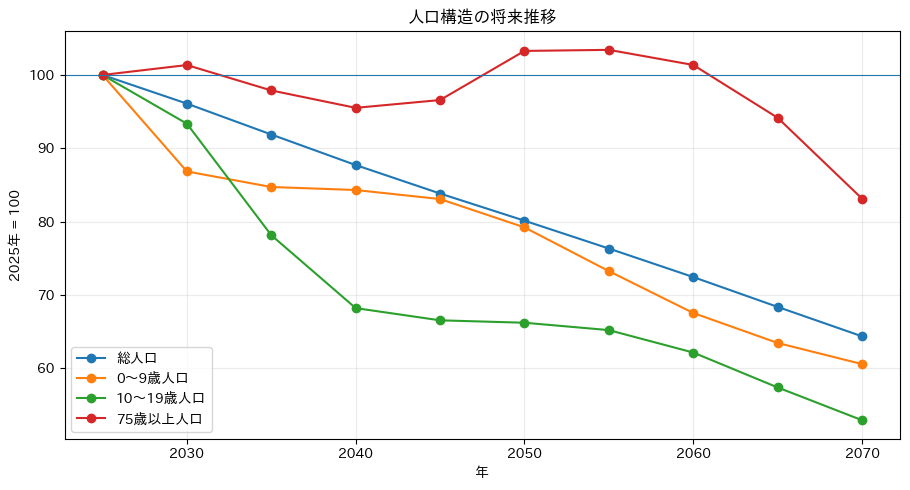

,年,総人口,0～9歳人口,10～19歳人口,75歳以上人口
0,2025,204335.0,14828.0,19497.0,41719.0
1,2030,196359.0,12878.0,18202.0,42283.0
2,2035,187753.0,12564.0,15239.0,40839.0
3,2040,179249.0,12503.0,13302.0,39850.0
4,2045,171318.0,12320.0,12977.0,40293.0
5,2050,163753.0,11748.0,12913.0,43086.0
6,2055,155999.0,10864.0,12717.0,43147.0
7,2060,148055.0,10018.0,12121.0,42288.0
8,2065,139745.0,9412.0,11194.0,39286.0
9,2070,131548.0,8985.0,10323.0,34687.0


In [25]:
# @title 人口推移
人口推移表 = population_trend(data["pop"], start_year=BASE_YEAR)
display(人口推移表)

## 4. ⛰️ 「500m」はみんな同じ？ ― 坂を考慮してバス停までの距離を見直す

ここで知りたいのは、**事業者に関係なく「使えるバス停が近くにあるか」**です。

この分析では、国土数値情報P11に収録された周辺の全バス停から、
250mメッシュごとに最も近いバス停を探します。

### 「坂道補正距離」とは？

平地を300m歩くのと、急な坂を300m歩くのでは負担が違います。  
そこで、バス停までの直線距離をメッシュの平均傾斜に応じて長めに補正します。

| 250mメッシュの平均傾斜 | 補正倍率 | 直線距離300mなら |
|---:|---:|---:|
| 3°未満 | ×1.00 | 300m相当 |
| 3～5° | ×1.25 | 375m相当 |
| 5～8° | ×1.67 | 約500m相当 |
| 8°以上 | ×2.50 | 750m相当 |

**坂道補正距離 ＝ 最寄りバス停までの直線距離 × 坂の補正倍率**

例えば、直線距離300m・平均傾斜6°なら、

> 300m × 1.67 ≒ **500m相当**

として扱います。

> ⚠️ **注意**  
> 坂道補正距離は、公的な基準や実際の徒歩経路距離ではありません。  
> 250mメッシュの平均傾斜を使い、**坂を考慮するとアクセス評価がどの程度変わるかを見るための講習用指標**です。

### 距離はどこから測る？

距離は、250mメッシュの**代表点**から最寄りバス停まで測ります。

同じメッシュ内にバス停があっても、代表点からは離れている場合があります。  
そこで交通空白候補を抽出するときは、

> **同じ250mメッシュ内にバス停が1つでもあれば候補から除外**

します。

### 地図の見方

- **メッシュの色**：バス停までの坂道補正距離
- **黒い点**：周辺のバス停（全事業者）
- **黒い線**：周辺のバスルート（全事業者）

右上のレイヤ一覧で、表示する項目をON/OFFできます。

In [35]:
# @title 坂を考慮する距離の基準
坂道補正距離基準_m = 500 # @param {type:"slider", min:300, max:800, step:50}

人口メッシュ, メッシュ代表点 = analyze_access(
    data,
    catchment_m=坂道補正距離基準_m
)

人口メッシュ = add_effective_distance(人口メッシュ)

print(
    "坂道補正距離 = 最寄りバス停までの直線距離 × 坂の補正倍率"
)
print(
    f"今回の判定基準：{坂道補正距離基準_m}m"
)

同一メッシュ内バス停あり = int(
    人口メッシュ["same_mesh_stop"].sum()
)
print(
    f"同じ250mメッシュ内にバス停があるメッシュ："
    f"{同一メッシュ内バス停あり}件"
    "（交通空白候補から除外）"
)

print("\n【直線距離だけの場合と、坂を考慮した場合の比較】")
坂道補正距離比較 = effective_distance_comparison(
    人口メッシュ,
    threshold_m=坂道補正距離基準_m,
    base_year=BASE_YEAR,
    future_year=FUTURE_YEAR
)
display(坂道補正距離比較.round(1))

print("\n【坂道補正距離帯ごとの人口】")
坂道補正距離帯集計 = effective_distance_band_table(
    人口メッシュ,
    threshold_m=坂道補正距離基準_m,
    base_year=BASE_YEAR,
    future_year=FUTURE_YEAR
)
display(坂道補正距離帯集計.round(0))

坂道補正距離地図 = make_effective_distance_map(
    data,
    人口メッシュ,
    threshold_m=坂道補正距離基準_m,
    gtfs=None,
    active_st=None,
)
坂道補正距離地図

坂道補正距離 = 最寄りバス停までの直線距離 × 坂の補正倍率
今回の判定基準：500m
同じ250mメッシュ内にバス停があるメッシュ：155件（交通空白候補から除外）

【直線距離だけの場合と、坂を考慮した場合の比較】


,人口指標,直線距離500m以内(%),坂道補正距離500m以内(%),坂を考慮した変化(%ポイント)
0,2025年総人口,97.3,87.3,-10.1
1,2025年0～9歳人口,96.7,85.4,-11.3
2,2025年10～19歳人口,98.0,87.8,-10.2
3,2025年75歳以上人口,97.4,88.7,-8.8
4,2040年75歳以上人口,97.5,87.7,-9.8



【坂道補正距離帯ごとの人口】


,バス停までの坂道補正距離,250mメッシュ数,2025年総人口,2025年0～9歳人口,2025年10～19歳人口,2025年75歳以上人口,2040年75歳以上人口
0,300m未満,225,136115.0,9595.0,12748.0,28536.0,26896.0
1,300～500m,96,42189.0,3069.0,4369.0,8452.0,8051.0
2,500～750m,61,22977.0,1994.0,2195.0,4000.0,4204.0
3,750m以上,20,3055.0,170.0,185.0,731.0,699.0


## 5. 🎯 「遠い × 人がいる」を探そう ― 潜在需要メッシュの抽出

公共交通の改善を考える候補を、次の2条件で絞ります。

1. **バス停までの坂道補正距離が基準以上**
2. **注目する人口が設定した人数以上**

### 注目する人口を選ぶ

- **2025年総人口**：地域全体の潜在需要
- **2025年0～9歳人口**：幼児・小学生世代
- **2025年10～19歳人口**：中高生世代
- **2025年75歳以上人口**：現在の高齢者移動需要
- **2040年75歳以上人口**：将来の高齢者移動需要
- **75歳以上人口増加（2025→2040）**：今後課題が大きくなりそうな地域

In [37]:
# @title 潜在需要を選ぶ
潜在需要指標 = "2025年総人口" # @param ["2025年総人口", "2025年0～9歳人口", "2025年10～19歳人口", "2025年75歳以上人口", "2040年75歳以上人口", "75歳以上人口増加（2025→2040）"]
人口閾値 = 10 # @param {type:"number"}

if "人口メッシュ" not in globals() or "メッシュ代表点" not in globals():

    if "坂道補正距離基準_m" not in globals():
        坂道補正距離基準_m = 500

    人口メッシュ, メッシュ代表点 = analyze_access(
        data,
        catchment_m=坂道補正距離基準_m
    )

    人口メッシュ = add_effective_distance(
        人口メッシュ
    )

    print(
        f"坂道補正距離の基準を "
        f"{坂道補正距離基準_m}m として準備しました。"
    )

抽出メッシュ, 指標列 = selected_meshes(
    data,
    人口メッシュ,
    メッシュ代表点,
    潜在需要指標,
    人口閾値,
    effective_distance_threshold_m=坂道補正距離基準_m
)

抽出結果 = japanese_priority_table(
    data,
    抽出メッシュ,
    潜在需要指標,
    指標列
)

print(f"バス停までの坂道補正距離：{坂道補正距離基準_m}m以上")
print(f"{潜在需要指標} が {人口閾値}人以上")
print("抽出メッシュ数:", len(抽出結果))
display(抽出結果.head(20).round(1))

抽出メッシュ地図 = selected_mesh_map(
    data,
    抽出メッシュ,
    指標列,
    潜在需要指標,
    人口閾値
)
抽出メッシュ地図

バス停までの坂道補正距離：500m以上
2025年総人口 が 10人以上
抽出メッシュ数: 79


,250mメッシュ,2025年総人口,坂道補正距離(m),最寄りバス停までの直線距離(m),平均傾斜（度 / 勾配%）,最寄り既存バスルートまで(m),停留所追加時の新規カバー対象人口(人)
34,5135705534,1231.0,573.0,573.0,1.7° / 3.0%,529.0,5473.1
32,5135705532,533.9,986.3,789.0,4.4° / 7.7%,754.0,4522.5
33,5135705533,917.7,565.9,452.7,3.1° / 5.4%,428.8,4287.7
90,5135706511,970.0,507.2,405.7,3.7° / 6.5%,403.8,3919.4
37,5135705543,1005.0,523.4,523.4,2.3° / 4.0%,467.4,3670.0
35,5135705541,199.8,942.2,753.8,4.2° / 7.3%,692.3,3670.0
31,5135705531,615.6,741.6,593.3,3.9° / 6.8%,533.6,3317.7
38,5135705544,687.4,774.3,619.4,4.6° / 8.0%,464.9,2931.6
95,5135706522,725.6,738.3,443.0,5.6° / 9.8%,252.3,2642.7
106,5135706611,224.6,787.9,472.8,6.9° / 12.1%,445.1,1938.4


### 🔍 表の読み方

- **坂道補正距離(m)**：最寄りバス停までの直線距離を、坂の負担に応じて補正した距離
- **最寄りバス停までの直線距離(m)**：250mメッシュ代表点から最寄りバス停までの平面距離
- **平均傾斜（度 / 勾配%）**：250mメッシュの平均的な地形の傾き
- **最寄り既存バスルートまで(m)**：周辺の既存バスルートまでの最短距離
- **停留所追加時の新規カバー対象人口(人)**：候補メッシュ付近に停留所を置いたと仮定したとき、新たに基準内となる対象人口の概算

> 💡 **見方のコツ**  
> 注目する人口が多く、坂道補正距離が長く、既存ルートには比較的近い場所は、  
> 停留所追加・移設や小規模な経路変更を検討する候補になり得ます。

# Part B　🕐 GTFSで「いつ・どれだけ走る？」を見てみよう

ここからは、大和郡山市コミュニティバスの公開GTFSを使います。

**GTFS**は、バスや鉄道の時刻表・路線・停留所を共通形式で保存したデータです。

GISが「どこ？」を得意とするのに対し、GTFSを加えると
**「いつ？」「何便？」**まで見えるようになります。

> 王寺町・山陽バスの改善を直接分析するためというより、  
> **GTFSが使えると公共交通分析がどこまで広がるか**を体験するパートです。

## 6. 📦 GTFSを読み込む

公開されている大和郡山市コミュニティバスのGTFSをGTFSデータレポジトリから自動で取得します。

In [27]:
# @title GTFSを読み込む

if globals().get("USE_CUSTOM_GTFS", False):
    print("指定した自治体の静的GTFSを使います。")
else:
    GTFS = load_gtfs(YAMATOKORIYAMA_GTFS_URL)
    gtfs = GTFS
    print("大和郡山市コミュニティバスの静的GTFSを読み込みました。")

大和郡山市コミュニティバスの静的GTFSを読み込みました。


## 7. 🚌 どんな路線がある？

まず、GTFSに収録されている路線を確認します。

GTFSには多くの項目がありますが、ここでは分析に使う**路線名**を一覧で表示します。

In [28]:
# @title 路線一覧
路線一覧 = route_name_table(gtfs)[["路線名"]].drop_duplicates()
display(路線一覧.reset_index(drop=True))

,路線名
0,元気治道号
1,元気平和号
2,元気城下町号


## 8. 📅 平日と土日で、どれくらい走る？

路線ごとの「時刻表上の供給量」を比べます。

- **平日平均便数**：GTFS有効期間中の月～金について、1日あたり何便走るかの平均
- **土日平均便数**：土曜日・日曜日の1日あたり平均便数

### 💡 0便はエラーではありません

大和郡山市コミュニティバスは、**月曜日～金曜日に運行し、土日祝日は運休**です。

そのため、この教材では

> **平日：約7便／日、土日：0便／日**

のような結果が出るのが正常です。

ここから、

> 「GTFSを見ると、単に路線があるかだけでなく、**いつ使える公共交通なのか**まで分かる」

という点を確認します。

> **便数**は時刻表上の予定運行回数であり、利用者数ではありません。

In [29]:
# @title 平日・土日の路線別平均便数
路線別平均便数 = average_route_service(gtfs)

路線別平均便数["土日の運行"] = np.where(
    路線別平均便数["土日平均便数"] > 0,
    "あり",
    "なし（運休）"
)

display(路線別平均便数.round(1))

print(
    "※ 大和郡山市コミュニティバスは土日祝運休のため、"
    "土日平均便数が0なのは正しい結果です。"
)

区分,路線名,平日平均便数,土日平均便数,土日の運行
0,元気平和号,7.0,0.0,なし（運休）
1,元気治道号,6.0,0.0,なし（運休）
2,元気城下町号,6.0,0.0,なし（運休）


※ 大和郡山市コミュニティバスは土日祝運休のため、土日平均便数が0なのは正しい結果です。


## 9. ⏰ 何時に走っている？ ― 時間帯別便数

各便について、**最初の停留所を出発する時刻**を使って時間帯別に数えます。

例えば8時の棒が大きければ、「8時台に出発する便が多い」という意味です。  
通勤・通学時間帯と昼間で、サービスの厚みがどう違うか見てみましょう。

グラフの色は路線を表し、凡例は右側に表示します。

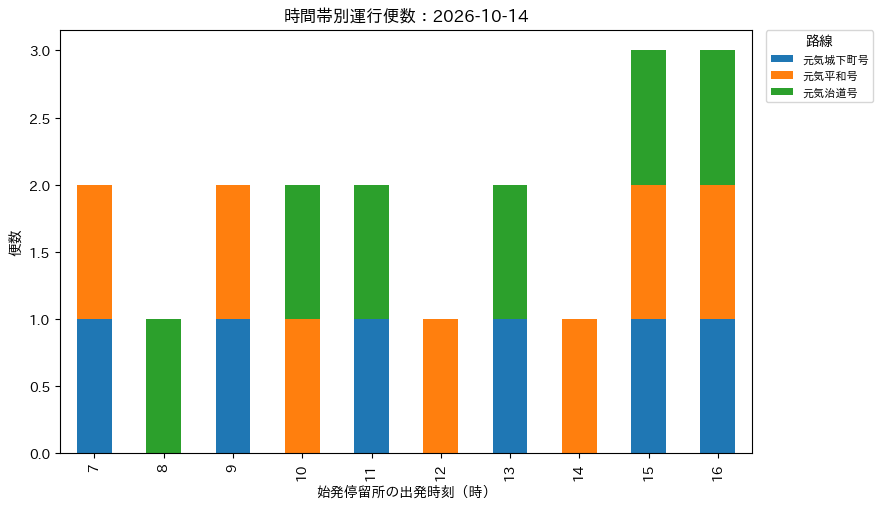

In [30]:
# @title 分析日と時間帯別便数
分析日 = "2026-10-14" # @param {type:"date"}

運行便, 停車時刻 = selected_day_data(
    gtfs,
    分析日
)

時間帯別便数 = hourly_by_route(
    gtfs,
    停車時刻
)

fig, ax = plt.subplots(
    figsize=(11.5, 5.2)
)

時間帯別便数.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel(
    "始発停留所の出発時刻（時）"
)
ax.set_ylabel("便数")
ax.set_title(
    f"時間帯別運行便数：{分析日}"
)

# 凡例はグラフの外側へ
n_routes = len(時間帯別便数.columns)
legend_cols = 1 if n_routes <= 12 else 2

ax.legend(
    title="路線",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
    fontsize=8,
    ncol=legend_cols,
)

# 右側に凡例用の余白を確保
right_margin = 0.78 if legend_cols == 1 else 0.66

plt.tight_layout(
    rect=[0, 0, right_margin, 1]
)
plt.show()

## 10. 🗺️ 路線とサービス量を一枚の地図にしよう

地図では、

- **線の色**：GTFSの路線
- **停留所の円の大きさ**：選んだサービス指標

を表します。

円の大きさに使える指標は、

- **1日停車回数**：選択日に、その停留所へ停車する予定回数
- **朝6～9時**：6時台～8時台の停車予定回数
- **昼9～16時**：9時台～15時台の停車予定回数
- **夕16～19時**：16時台～18時台の停車予定回数

です。

> 円が大きいほど利用者が多い、という意味ではありません。  
> **時刻表上のサービス量が多い**ことを表します。

### 路線の線形について

GTFSに `shapes.txt` があれば、その線形を使います。  
`shapes.txt` がない場合は、停留所の並びを結んで代表的な経路を作ります。

自分の自治体で試す場合、GTFSから路線線形を作れないときは、
国土数値情報N07のバスルートを参考表示します。

In [31]:
# @title 地図に使う停留所指標
停留所サイズ指標 = "一日停車回数" # @param ["一日停車回数", "朝6_9", "昼9_16", "夕16_19"]

# GTFSから路線線形を作れない場合は、N07を参考表示します。
参考N07ルート = None

if globals().get("USE_CUSTOM_DATA", False):
    if (
        "focal_routes" in data
        and len(data["focal_routes"]) > 0
    ):
        参考N07ルート = data["focal_routes"]
    elif (
        "routes" in data
        and len(data["routes"]) > 0
    ):
        参考N07ルート = data["routes"]

GTFS地図, 停留所サービス = gtfs_service_map(
    gtfs,
    停車時刻,
    size_metric=停留所サイズ指標,
    fallback_routes=参考N07ルート,
)

GTFS地図

> 国土数値情報N07は事業者単位の経路データで、GTFSの各系統と1対1には対応しません。  
> そのため、路線別の色分けにはGTFSから作った経路を使います。

## 11. 🚏 停留所ごとの「サービスの厚み」を比べる

停留所ごとに、1日に何回バスが停まる予定かを集計します。

- **1日停車回数**：その日の全路線・全方向を合計した停車予定回数
- **朝6～9 / 昼9～16 / 夕16～19**：時間帯別の停車予定回数

同じ1日20回でも、朝夕に集中している停留所と、昼間にも走っている停留所では使いやすさが違います。

In [32]:
# @title 停留所別サービス水準
停留所サービス = stop_service_table(gtfs, 停車時刻)

display(
    停留所サービス[
        ["stop_name", "一日停車回数", "朝6_9", "昼9_16", "夕16_19"]
    ]
    .rename(columns={"stop_name": "停留所"})
    .sort_values("一日停車回数", ascending=False)
    .head(20)
)

,停留所,一日停車回数,朝6_9,昼9_16,夕16_19
38,大和郡山市役所,29,3,20,6
37,やまと郡山城ホール,26,3,17,6
25,JR郡山駅東口,24,3,17,4
39,近鉄郡山駅,24,3,15,6
74,さんて郡山,17,2,13,2
22,平和橋,13,2,8,3
35,小川町,12,1,8,3
15,老人福祉センター,11,2,7,2
68,JR郡山駅西口,11,2,7,2
73,青藍病院前,11,2,8,1


## 12. 👥 GTFS × 250m人口 ― 「人の多さ」と「便の多さ」を重ねる

停留所の周辺人口と、GTFSのサービス量を組み合わせます。

### 指標の定義

- **300m圏人口**：停留所から300m以内に代表点が入る250mメッシュの2025年人口の合計
- **300m圏75歳以上**：同じ範囲の2025年75歳以上人口
- **1日停車回数**：選択日にその停留所へ停車する予定回数
- **周辺人口÷停車回数（人/回）**：

周辺人口に対してサービス量が相対的に薄い場所を探すための**参考指標**です。
値が大きいほど「周辺人口の割に停車回数が少ない」可能性があります。

In [33]:
# @title 停留所周辺人口とサービス量
GTFS徒歩圏_m = 300 # @param {type:"slider", min:100, max:1000, step:50}

停留所サービス = stop_service_table(gtfs, 停車時刻)

# GTFSに対応する250m人口を使います。
if globals().get("USE_CUSTOM_DATA", False):
    GTFS分析用人口 = data["pop"].copy()
    print("指定した自治体の250m人口を使います。")
else:
    GTFS分析用人口 = load_yamatokoriyama_population()
    print("大和郡山市の250m人口を使います。")

GTFS人口サービス = gtfs_population_access(
    停留所サービス,
    GTFS分析用人口,
    catchment_m=GTFS徒歩圏_m
)

display(GTFS人口サービス.head(20).round(1))

大和郡山市の250m人口を使います。


,停留所,1日停車回数,300m圏人口,300m圏75歳以上,周辺人口÷停車回数(人/回)
36,小川町,4.0,2518.5,413.3,629.6
34,山本町,3.0,1778.4,342.8,592.8
33,山本町,4.0,1778.4,342.8,444.6
30,奈良口,3.0,1239.8,231.2,413.3
29,奈良口,4.0,1239.8,231.2,309.9
68,JR郡山駅西口,11.0,2870.4,586.7,260.9
63,郡山八幡神社,8.0,2019.7,383.3,252.5
32,ハローワーク前,6.0,1502.6,245.1,250.4
70,柳町,8.0,1902.3,185.7,237.8
31,近鉄九条駅,7.0,1548.2,337.5,221.2


## 13. 💡 最後のミッション ― 王寺町・垂水区ならどう改善する？

ここまでの地図と表を使って、

**「どこを・誰のために・どう改善するか」**
**潜在需要がありそうなのに、空間的・時間的なサービスが弱い場所を見つけること**

を考えてみてください。

考え終わったら、下の「解答例を見る」を開いてAIの解答例と比べてみましょう。

<details>
<summary><b>解答例を見る</b></summary>

### 王寺町の例

2040年75歳以上人口を選び、一定人数以上で、かつバス停までの坂道補正距離が長いメッシュを抽出する。

その中で既存バスルートに近い場所は、完全な新路線よりも、
停留所の追加・移設や小規模な経路変更で対応できる可能性がある。

既存ルートから遠い場所では、固定路線バスの延伸だけでなく、
DRTなど別の移動手段も比較する必要がある。

また、直線距離だけなら500m以内でも、坂を考慮するとアクセスが厳しくなる地域では、
実際の歩行経路・高低差・道路環境を追加確認する。

GTFSが利用できる場合は、昼間の便数も確認し、
高齢者人口が多い一方で昼間サービスが少ない地域なら、
「停留所を増やす」だけでなく「運行時間帯を見直す」という仮説も考えられる。

### 垂水区の例

垂水区では坂が多いため、直線距離だけでは見えにくいアクセス上の課題が
坂道補正距離によって見つかる可能性がある。

75歳以上人口が多い候補地域では、実際の道路経路や坂の向きを確認し、
停留所位置の見直し、小型車による補完、短距離フィーダーなどを比較する。

GTFSが利用できる場合は、駅方面への時間帯別便数も加え、
「バス停は近いが、必要な時間帯に便が少ない地区」を探すことができる。

# 参考：🌏 他の事例で試すには？

ここから下は、**今回の講習では実行しません**。  
講習後に、他の事例（自治体）へ応用したいときに使う参考部分です。

指定するのは、

- **都道府県名**
- **自治体名**
- **静的GTFS**

の3つです。

人口・傾斜・バス停・バスルートは、国土交通省の国土数値情報から取得します。

## 使用するデータ

| データ | 取得元 | 主な使い道 |
|---|---|---|
| 行政区域 | 国土数値情報 N03 | 対象自治体の特定 |
| 250m将来人口 | 国土数値情報 | 総人口・子ども・75歳以上など |
| 標高・傾斜 | 国土数値情報 G04-d | 坂道補正距離 |
| バス停 | 国土数値情報 P11 | 最寄りバス停 |
| バスルート | 国土数値情報 N07 | 既存路線との位置関係 |
| 時刻表 | 静的GTFS | 便数・時間帯・停留所サービス |

### 政令指定都市にも対応します

例えば、

- `自治体名 = "垂水区"` → 垂水区だけ
- `自治体名 = "神戸市"` → 神戸市全体

として分析できます。

### 別の自治体へ切り替えるとき

例えば神戸の次に札幌を分析する場合は、

1. **①** で都道府県・自治体・静的GTFSを指定
2. **③** で自治体データを準備
3. 上に戻って **3. から順に実行**

します。同じColabセッションでは、②の関数セルは通常1回実行すれば十分です。

### 王寺町・垂水区へ戻るとき

上の **2. 対象地域を選ぶ** をもう一度実行し、  
その後 **3. から順に実行**してください。

> 自分の自治体を初めて読み込むときは、都道府県単位の公式データを取得するため、少し時間がかかる場合があります。

## 0. 🧰 参考部分だけ実行する場合の準備

この「自分の自治体版」だけを試す場合は、
**本編の「1. 準備」を実行しなくても大丈夫**です。

代わりに、次のセルを最初に1回だけ実行してください。

> 本編の「1. 準備」をすでに実行している場合は、このセルは飛ばして構いません。

In [ ]:
# @title 参考部分だけ実行する場合のライブラリ準備
import importlib.util
import subprocess
import sys

required = {
    "geopandas": "geopandas",
    "pyogrio": "pyogrio",
    "folium": "folium",
    "japanize_matplotlib": "japanize-matplotlib",
    "requests": "requests",
    "bs4": "beautifulsoup4",
}

missing = [
    pkg
    for mod, pkg in required.items()
    if importlib.util.find_spec(mod) is None
]

if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing]
    )

print("✅ 参考部分の実行準備ができました。")

## 🚌 静的GTFSはどこから入手する？

おすすめは **[GTFSデータリポジトリ](https://gtfs-data.jp/search)** です。

例えば兵庫県のフィードは、都道府県を「兵庫県」にして検索できます。

### 方法A：現行GTFSのダウンロードURLを使う

1. GTFSデータリポジトリで自治体・事業者を検索
2. 対象フィードの「詳細」を開く
3. **「現行」** のGTFSを確認
4. `DL` または `GTFS` から取得できる**現行データのダウンロードURL**をコピー
5. 下の `GTFS_URL_自治体` に貼り付ける

> 「過去版」ではなく、原則として**現行**を使います。  
> 有効期間も確認してください。

### 方法B：静的GTFSのZIPをアップロードする

URLをコピーしにくい場合は、

1. GTFSデータリポジトリから現行GTFSをZIPでダウンロード
2. ColabへZIPをアップロード
3. ZIPのファイル名を `GTFS_ZIP_自治体` に指定

でも構いません。

### ⚠️ 今回使うのは「静的GTFS」です

このノートブックで使うのは、

- `agency.txt`
- `routes.txt`
- `trips.txt`
- `stops.txt`
- `stop_times.txt`
- `calendar.txt` / `calendar_dates.txt`

などが入った**静的GTFS（ZIP）**です。

**GTFS-Realtime（GTFS-RT）ではありません。**

GTFS-RTは車両位置・遅延・運行情報などのリアルタイムデータで、
今回の「時刻表上の便数・時間帯・停留所サービス水準」の分析とは別物です。

In [ ]:
# @title ① 自分の自治体と静的GTFSを指定する
都道府県名 = "兵庫県" # @param {type:"string"}
自治体名 = "神戸市" # @param {type:"string"}

GTFSの指定方法 = "URL" # @param ["URL", "ZIPファイル"]

# 方法A：GTFSデータリポジトリ等の「現行」静的GTFSダウンロードURL
GTFS_URL_自治体 = "https://example.com/current_gtfs.zip" # @param {type:"string"}

# 方法B：Colabにアップロードした静的GTFS ZIP
GTFS_ZIP_自治体 = "" # @param {type:"string"}

print("都道府県:", 都道府県名)
print("自治体:", 自治体名)
print("GTFS指定方法:", GTFSの指定方法)

if GTFSの指定方法 == "URL":
    print("静的GTFS URL:", GTFS_URL_自治体)
else:
    print("静的GTFS ZIP:", GTFS_ZIP_自治体)

### 💻 ZIPをColabへアップロードする場合

ZIP方式を使う場合だけ、次のセルを実行します。

アップロード後、取得したファイル名を
`GTFS_ZIP_自治体` に自動設定します。

In [ ]:
# @title （ZIP方式のみ）静的GTFS ZIPをアップロード
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("ファイルが選択されませんでした。")

GTFS_ZIP_自治体 = next(iter(uploaded.keys()))
GTFSの指定方法 = "ZIPファイル"

print("使用する静的GTFS:", GTFS_ZIP_自治体)

In [ ]:
# @title ② 自動取得用の関数（通常は開かなくて構いません）
import re
import io
import shutil
import zipfile
from pathlib import Path
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from bs4 import BeautifulSoup
import math
import matplotlib.pyplot as plt
import japanize_matplotlib
import folium
from IPython.display import display, Markdown
from branca.colormap import linear

PREF_CODES = {
    "北海道":"01","青森県":"02","岩手県":"03","宮城県":"04","秋田県":"05",
    "山形県":"06","福島県":"07","茨城県":"08","栃木県":"09","群馬県":"10",
    "埼玉県":"11","千葉県":"12","東京都":"13","神奈川県":"14","新潟県":"15",
    "富山県":"16","石川県":"17","福井県":"18","山梨県":"19","長野県":"20",
    "岐阜県":"21","静岡県":"22","愛知県":"23","三重県":"24","滋賀県":"25",
    "京都府":"26","大阪府":"27","兵庫県":"28","奈良県":"29","和歌山県":"30",
    "鳥取県":"31","島根県":"32","岡山県":"33","広島県":"34","山口県":"35",
    "徳島県":"36","香川県":"37","愛媛県":"38","高知県":"39","福岡県":"40",
    "佐賀県":"41","長崎県":"42","熊本県":"43","大分県":"44","宮崎県":"45",
    "鹿児島県":"46","沖縄県":"47"
}

CUSTOM_DIR = Path("custom_municipality_data")
CUSTOM_DIR.mkdir(exist_ok=True)


ROUTE_COLORS = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "cadetblue", "darkgreen", "pink", "gray"
]


def download_file(url, path):
    path = Path(path)

    if path.exists() and path.stat().st_size > 100:
        return path

    r = requests.get(
        url,
        timeout=240,
        allow_redirects=True,
        headers={
            "User-Agent": "Mozilla/5.0"
        },
    )

    try:
        r.raise_for_status()
    except requests.HTTPError as e:
        raise requests.HTTPError(
            f"ダウンロードできませんでした ({r.status_code}): {url}"
        ) from e

    path.write_bytes(r.content)

    return path


def resolve_ksj_url_from_official_page(detail_page_url, target_filename):
    """
    国土数値情報の公式データ詳細ページから、
    target_filename に対応する実ダウンロードURLを探す。

    公式ページのHTML構造が変わってもある程度対応できるよう、
    href / onclick / data-* 属性を広めに探索する。
    """
    r = requests.get(
        detail_page_url,
        timeout=120,
        headers={"User-Agent": "Mozilla/5.0"},
    )
    r.raise_for_status()

    html = r.text
    soup = BeautifulSoup(html, "html.parser")

    # 1. ファイル名を含む行を探して、その行内の属性を調べる
    target_node = soup.find(
        string=lambda x:
        isinstance(x, str) and target_filename in x
    )

    candidate_texts = []

    if target_node is not None:
        row = target_node.find_parent("tr")

        if row is not None:
            for tag in row.find_all(True):
                for attr, value in tag.attrs.items():
                    if isinstance(value, list):
                        value = " ".join(map(str, value))
                    candidate_texts.append(str(value))

    # 2. ページ全体の target_filename 周辺も候補にする
    idx = html.find(target_filename)
    if idx >= 0:
        candidate_texts.append(
            html[max(0, idx - 1500): idx + 1500]
        )

    # URL / 相対パスを抽出
    patterns = [
        rf'https?://[^"\'<>\s]*{re.escape(target_filename)}',
        rf'[^"\'<>\s]*{re.escape(target_filename)}',
    ]

    for text in candidate_texts:
        for pattern in patterns:
            hits = re.findall(pattern, text)

            for hit in hits:
                hit = hit.replace("\\/", "/")
                if target_filename not in hit:
                    continue

                candidate = urljoin(detail_page_url, hit)

                # 実際に存在するかHEAD/GETで確認
                try:
                    rr = requests.get(
                        candidate,
                        timeout=60,
                        stream=True,
                        allow_redirects=True,
                        headers={
                            "User-Agent": "Mozilla/5.0",
                            "Referer": detail_page_url,
                        },
                    )

                    if rr.status_code == 200:
                        rr.close()
                        return candidate

                    rr.close()
                except Exception:
                    pass

    return None


def resolve_ksj_url_from_metadata_api(
    dataset_id,
    target_year,
    target_filename,
):
    """
    公式ページからURLを抽出できない場合のフォールバック。

    jpksj-api は国土数値情報の公式ページを機械判読しやすくした
    メタデータサービス。ここでは URL の特定だけに利用し、
    実データ本体は必ず file_url の国土交通省公式URLから取得する。
    """
    base = "https://jpksj-api.kmproj.com"

    dataset_meta = requests.get(
        f"{base}/datasets/{dataset_id}.json",
        timeout=60,
    )
    dataset_meta.raise_for_status()
    meta = dataset_meta.json()

    versions = meta.get("versions", [])

    version_id = None

    # まず年が範囲内のversionを選ぶ
    for v in versions:
        start = v.get("start_year")
        end = v.get("end_year")

        if (
            isinstance(start, int)
            and isinstance(end, int)
            and start <= target_year <= end
        ):
            version_id = v.get("id")
            break

    # 次にidが年そのものなら採用
    if version_id is None:
        for v in versions:
            if str(v.get("id")) == str(target_year):
                version_id = v.get("id")
                break

    if version_id is None:
        raise RuntimeError(
            f"{dataset_id} の {target_year} 年版を"
            "メタデータから特定できませんでした。"
        )

    detail = requests.get(
        f"{base}/datasets/{dataset_id}/{version_id}.json",
        timeout=60,
    )
    detail.raise_for_status()
    detail_json = detail.json()

    for f in detail_json.get("files", []):
        file_url = str(f.get("file_url", ""))

        if file_url.endswith(target_filename):
            # 実データが国交省公式URLであることを確認
            if "nlftp.mlit.go.jp" not in file_url:
                raise RuntimeError(
                    "取得候補URLが国土交通省公式URLではありません。"
                )
            return file_url

    raise RuntimeError(
        f"{target_filename} の公式URLを"
        "メタデータから見つけられませんでした。"
    )


def resolve_ksj_download_url(
    detail_page_url,
    dataset_id,
    target_year,
    target_filename,
):
    """
    1) 公式ページを直接解析
    2) だめならメタデータサービスでURLだけ解決
    の順で、実データの国交省公式URLを取得する。
    """
    url = resolve_ksj_url_from_official_page(
        detail_page_url,
        target_filename
    )

    if url is not None:
        print(
            "公式ページからダウンロードURLを自動取得:",
            target_filename
        )
        return url

    print(
        "公式ページからURLを直接取得できなかったため、"
        "機械判読用メタデータから公式URLを確認します:",
        target_filename
    )

    return resolve_ksj_url_from_metadata_api(
        dataset_id=dataset_id,
        target_year=target_year,
        target_filename=target_filename,
    )


def unzip_vector(zip_path, out_dir):
    """
    ZIPを解凍し、読み込めるGISファイルを探す。
    """
    out_dir = Path(out_dir)

    if out_dir.exists():
        shutil.rmtree(out_dir)

    out_dir.mkdir(parents=True)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)

    candidates = []

    for ext in ["*.geojson", "*.shp", "*.gpkg", "*.gml", "*.xml"]:
        candidates.extend(out_dir.rglob(ext))

    for f in candidates:
        try:
            try:
                g = gpd.read_file(f, encoding="CP932")
            except Exception:
                g = gpd.read_file(f)

            if len(g):
                return g
        except Exception:
            pass

    raise RuntimeError(
        f"ZIP内のGISデータを読み込めませんでした: {zip_path}"
    )


def read_static_gtfs_zip(raw_bytes):
    """
    静的GTFS ZIPのバイト列を読み込み、
    {ファイル名: DataFrame} の辞書として返す。
    """
    if raw_bytes[:2] != b"PK":
        raise ValueError(
            "取得したデータはZIPではありません。"
            "GTFSデータリポジトリの『現行』静的GTFSの"
            "ダウンロードURLを指定してください。"
        )

    gtfs = {}

    with zipfile.ZipFile(io.BytesIO(raw_bytes)) as zf:
        for name in zf.namelist():
            if name.lower().endswith(".txt"):
                gtfs[Path(name).stem] = pd.read_csv(
                    io.BytesIO(zf.read(name)),
                    dtype=str,
                    encoding="utf-8-sig",
                    low_memory=False,
                )

    required = {"routes", "trips", "stops", "stop_times"}
    missing = required - set(gtfs)

    if missing:
        raise ValueError(
            "静的GTFSに必要なファイルが不足しています: "
            + ", ".join(sorted(missing))
        )

    return gtfs


def load_static_gtfs_source(method, url="", zip_path=""):
    """
    静的GTFSをURLまたはローカルZIPから読み込む。

    この関数は本編の load_gtfs() に依存しないので、
    参考部分だけを実行しても動く。
    """
    if method == "URL":
        if not url or "example.com" in url:
            raise ValueError(
                "GTFSデータリポジトリ等で、"
                "『現行』静的GTFSのダウンロードURLを指定してください。"
            )

        r = requests.get(
            url,
            timeout=180,
            allow_redirects=True,
        )
        r.raise_for_status()

        return read_static_gtfs_zip(r.content)

    if method == "ZIPファイル":
        if not zip_path:
            raise ValueError(
                "静的GTFS ZIPをアップロードして"
                "ファイル名を指定してください。"
            )

        path = Path(zip_path)

        if not path.exists():
            raise FileNotFoundError(
                f"静的GTFS ZIPが見つかりません: {zip_path}"
            )

        return read_static_gtfs_zip(path.read_bytes())

    raise ValueError(
        "GTFSの指定方法は『URL』または『ZIPファイル』を選んでください。"
    )


def fetch_municipality_boundary(pref_name, municipality_name):
    """
    最新N03行政区域から対象範囲を取得する。

    対応例:
      王寺町   -> 1つの市町村コード
      垂水区   -> N03_005の行政区名から 28108
      神戸市   -> 神戸市内の全行政区コードをまとめて対象にする

    古いN03（N03_005がない版）にもなるべく対応する。
    """
    pref_code = PREF_CODES[pref_name]

    # 2026年版の公式N03を利用
    filename = f"N03-20260101_{pref_code}_GML.zip"
    url = (
        "https://nlftp.mlit.go.jp/ksj/gml/data/"
        f"N03/N03-2026/{filename}"
    )

    zpath = download_file(
        url,
        CUSTOM_DIR / filename
    )

    admin = unzip_vector(
        zpath,
        CUSTOM_DIR / f"N03-2026_{pref_code}"
    )

    if admin.crs is None:
        admin = admin.set_crs(
            epsg=6668,
            allow_override=True
        )

    admin = admin.to_crs(4326)

    c3 = admin.get(
        "N03_003",
        pd.Series("", index=admin.index)
    ).fillna("").astype(str)

    c4 = admin.get(
        "N03_004",
        pd.Series("", index=admin.index)
    ).fillna("").astype(str)

    c5 = admin.get(
        "N03_005",
        pd.Series("", index=admin.index)
    ).fillna("").astype(str)

    # 優先順位:
    # 1. 政令市の行政区名（例: 垂水区）
    # 2. 市区町村名（例: 王寺町、神戸市）
    # 3. 旧N03の政令市名（例: 神戸市がN03_003に入る場合）
    if (c5 == municipality_name).any():
        hit = admin.loc[c5 == municipality_name].copy()
        matched_as = "行政区"

    elif (c4 == municipality_name).any():
        hit = admin.loc[c4 == municipality_name].copy()
        matched_as = "市区町村"

    elif (c3 == municipality_name).any():
        hit = admin.loc[c3 == municipality_name].copy()
        matched_as = "政令指定都市（旧形式）"

    else:
        raise ValueError(
            f"{pref_name} の行政区域から「{municipality_name}」"
            "を見つけられませんでした。"
        )

    if "N03_007" not in hit.columns:
        raise ValueError(
            "行政区域データに全国地方公共団体コード N03_007 がありません。"
        )

    hit["N03_007"] = (
        hit["N03_007"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(5)
    )

    municipality_codes = sorted(
        hit["N03_007"]
        .dropna()
        .loc[lambda x: x != ""]
        .unique()
        .tolist()
    )

    if not municipality_codes:
        raise ValueError(
            f"「{municipality_name}」の自治体コードを取得できませんでした。"
        )

    # 政令市を指定した場合は複数の行政区コードを持つのが正常。
    # 例: 神戸市 -> 28101, 28102, ... 28111
    boundary = (
        hit[["geometry"]]
        .dissolve()
        .reset_index(drop=True)
    )

    boundary["対象名"] = municipality_name
    boundary["検索区分"] = matched_as

    print(
        f"行政区域: {municipality_name} "
        f"({matched_as}) / 対象コード数={len(municipality_codes)}"
    )

    if len(municipality_codes) <= 12:
        print("対象自治体コード:", ", ".join(municipality_codes))

    return boundary, municipality_codes, pref_code


def fetch_future_population_official(
    pref_code,
    municipality_codes
):
    """
    国土数値情報
    250mメッシュ別将来推計人口データ（R6国政局推計）
    の都道府県別GeoJSON ZIPを取得する。

    ファイル名は公式ページで確認し、
    実データ本体は国土交通省公式URLからダウンロードする。
    """
    filename = (
        f"250m_mesh_2024_{pref_code}_GEOJSON.zip"
    )

    detail_page = (
        "https://nlftp.mlit.go.jp/ksj/gml/datalist/"
        "KsjTmplt-mesh250r6.html"
    )

    url = resolve_ksj_download_url(
        detail_page_url=detail_page,
        dataset_id="m250r6",
        target_year=2024,
        target_filename=filename,
    )

    print("将来人口を取得:", url)

    zpath = download_file(
        url,
        CUSTOM_DIR / filename
    )

    pop = unzip_vector(
        zpath,
        CUSTOM_DIR / f"future_population_{pref_code}"
    )

    if pop.crs is None:
        pop = pop.set_crs(
            epsg=6668,
            allow_override=True
        )

    pop = pop.to_crs(4326)

    pop["SHICODE"] = (
        pop["SHICODE"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(5)
    )

    pop = pop.loc[
        pop["SHICODE"].isin(municipality_codes)
    ].copy()

    if pop.empty:
        raise RuntimeError(
            "将来人口データから対象自治体を抽出できませんでした。"
        )

    pop["MESH_ID"] = (
        pop["MESH_ID"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
    )

    return pop.drop_duplicates("MESH_ID")


def fetch_slope_for_population(pop):
    """
    MESH_ID先頭4桁から必要なG04-dだけを自動取得。
    """
    first_meshes = sorted(
        pop["MESH_ID"]
        .astype(str)
        .str[:4]
        .dropna()
        .unique()
    )

    parts = []

    for mesh4 in first_meshes:
        filename = (
            f"G04-d-11_{mesh4}-jgd_GML.zip"
        )

        url = (
            "https://nlftp.mlit.go.jp/ksj/gml/data/"
            "G04-d/G04-d-11/"
            f"{filename}"
        )

        try:
            zpath = download_file(
                url,
                CUSTOM_DIR / filename
            )

            g = unzip_vector(
                zpath,
                CUSTOM_DIR / f"G04-d-11_{mesh4}"
            )
        except Exception as e:
            print(
                f"傾斜データ {mesh4} を取得できませんでした:",
                e
            )
            continue

        if g.crs is None:
            g = g.set_crs(
                epsg=4612,
                allow_override=True
            )

        rename_map = {
            "G04d_001": "mesh_code",
            "G04d_002": "elev_mean_m",
            "G04d_003": "elev_max_m",
            "G04d_004": "elev_min_m",
            "G04d_006": "slope_max_deg",
            "G04d_010": "slope_mean_deg",
        }

        g = g.rename(
            columns={
                k: v for k, v in rename_map.items()
                if k in g.columns
            }
        )

        if (
            "mesh_code" not in g.columns
            or "slope_mean_deg" not in g.columns
        ):
            print(
                f"{mesh4}: 必要な傾斜属性がありません。"
            )
            continue

        keep = [
            c for c in [
                "mesh_code",
                "elev_mean_m",
                "elev_max_m",
                "elev_min_m",
                "slope_max_deg",
                "slope_mean_deg",
            ]
            if c in g.columns
        ]

        x = g[keep].copy()

        x["mesh_code"] = (
            x["mesh_code"]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
        )

        for c in keep:
            if c != "mesh_code":
                x[c] = pd.to_numeric(
                    x[c],
                    errors="coerce"
                )

        parts.append(x)

    if not parts:
        raise RuntimeError(
            "傾斜データを取得できませんでした。"
        )

    return (
        pd.concat(parts, ignore_index=True)
        .drop_duplicates("mesh_code")
    )


def fetch_ksj_prefecture_shp(
    dataset,
    year2,
    pref_code
):
    """
    P11バス停 / N07バスルートを都道府県単位で取得。

    URLを決め打ちせず、公式ページから対象ファイルのURLを解決する。
    """
    year4 = 2000 + int(year2)

    filename = (
        f"{dataset}-{year2}_{pref_code}_SHP.zip"
    )

    detail_page = (
        "https://nlftp.mlit.go.jp/ksj/gml/datalist/"
        f"KsjTmplt-{dataset}-{year4}.html"
    )

    url = resolve_ksj_download_url(
        detail_page_url=detail_page,
        dataset_id=dataset,
        target_year=year4,
        target_filename=filename,
    )

    print(f"{dataset} を取得:", url)

    zpath = download_file(
        url,
        CUSTOM_DIR / filename
    )

    g = unzip_vector(
        zpath,
        CUSTOM_DIR / f"{dataset}-{year2}_{pref_code}"
    )

    if g.crs is None:
        g = g.set_crs(
            epsg=6668,
            allow_override=True
        )

    return g.to_crs(4326)


def normalize_operator_name(x):
    s = str(x)

    for token in [
        "株式会社", "有限会社", "（株）", "(株)",
        " ", "　", "バス株式会社"
    ]:
        s = s.replace(token, "")

    return s


def gtfs_agency_name(gtfs):
    if (
        "agency" in gtfs
        and "agency_name" in gtfs["agency"].columns
    ):
        x = (
            gtfs["agency"]["agency_name"]
            .dropna()
            .astype(str)
        )

        if len(x):
            return x.iloc[0]

    return "対象GTFS"


def operator_mask(series, operator):
    target = normalize_operator_name(operator)

    normalized = (
        series.fillna("")
        .astype(str)
        .map(normalize_operator_name)
    )

    return normalized.map(
        lambda x:
        ((target in x) or (x in target))
        if x and target
        else False
    )


def prepare_custom_municipality(
    pref_name,
    municipality_name,
    gtfs_method,
    gtfs_url="",
    gtfs_zip="",
    base_year=2025,
    future_year=2040,
):
    """
    国土数値情報の公式ZIP + 静的GTFSから、
    本編と同じ data / gtfs を作る。
    """

    # 1. 静的GTFS
    custom_gtfs = load_static_gtfs_source(
        method=gtfs_method,
        url=gtfs_url,
        zip_path=gtfs_zip,
    )

    operator = gtfs_agency_name(custom_gtfs)

    # 2. 行政区域・自治体コード
    boundary, municipality_codes, pref_code = (
        fetch_municipality_boundary(
            pref_name,
            municipality_name
        )
    )

    # 3. 250m将来人口（公式GeoJSON ZIP）
    pop = fetch_future_population_official(
        pref_code,
        municipality_codes
    )

    # 数値列
    for c in pop.columns:
        if re.fullmatch(
            r"PT(?:00|A|D|0[1-4])_\d{4}",
            str(c)
        ):
            pop[c] = pd.to_numeric(
                pop[c],
                errors="coerce"
            ).fillna(0)

    pop["mesh_code"] = (
        pop["MESH_ID"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
    )

    # 本編で使う標準列
    pop["pop_base"] = pop[f"PT00_{base_year}"]
    pop["child_base"] = pop[f"PTA_{base_year}"]
    pop["elderly_base"] = pop[f"PTD_{base_year}"]
    pop["pop_future"] = pop[f"PT00_{future_year}"]
    pop["elderly_future"] = pop[f"PTD_{future_year}"]
    pop["elderly_growth"] = (
        pop["elderly_future"]
        - pop["elderly_base"]
    )

    # 0～9歳・10～19歳（5歳階級をそのまま合計）
    pop["age_0_9_base"] = (
        pop[f"PT01_{base_year}"]
        + pop[f"PT02_{base_year}"]
    )

    pop["age_10_19_base"] = (
        pop[f"PT03_{base_year}"]
        + pop[f"PT04_{base_year}"]
    )

    # 4. 傾斜
    slope = fetch_slope_for_population(pop)

    slope_keep = [
        c for c in [
            "mesh_code",
            "slope_mean_deg",
            "slope_max_deg",
            "elev_mean_m",
        ]
        if c in slope.columns
    ]

    pop = pop.merge(
        slope[slope_keep],
        on="mesh_code",
        how="left"
    )

    # 5. 全事業者のP11バス停 / N07バスルート
    stops_all = fetch_ksj_prefecture_shp(
        "P11",
        "22",
        pref_code
    )

    routes_all = fetch_ksj_prefecture_shp(
        "N07",
        "22",
        pref_code
    )

    metric_crs = pop.estimate_utm_crs()
    pop_m = pop.to_crs(metric_crs)

    study_geom_m = (
        pop_m.geometry.union_all()
        .buffer(1500)
    )

    study_geom = gpd.GeoSeries(
        [study_geom_m],
        crs=metric_crs
    ).to_crs(4326).iloc[0]

    stops = stops_all.loc[
        stops_all.intersects(study_geom)
    ].copy()

    routes = routes_all.loc[
        routes_all.intersects(study_geom)
    ].copy()

    # 6. GTFSのagency名を使って対象事業者を推定
    if "P11_002" in stops.columns:
        focal_stops = stops.loc[
            operator_mask(
                stops["P11_002"],
                operator
            )
        ].copy()
    else:
        focal_stops = stops.iloc[0:0].copy()

    if "N07_001" in routes.columns:
        focal_routes = routes.loc[
            operator_mask(
                routes["N07_001"],
                operator
            )
        ].copy()
    else:
        focal_routes = routes.iloc[0:0].copy()

    cfg = {
        "pref": pref_code,
        "shicode": (
            municipality_codes[0]
            if len(municipality_codes) == 1
            else municipality_codes
        ),
        "operator": operator,
        "label": f"{pref_name}{municipality_name}",
    }

    custom_data = {
        "cfg": cfg,
        "pop": pop,
        "stops": stops,
        "routes": routes,
        "focal_stops": focal_stops,
        "focal_routes": focal_routes,
        "metric_crs": metric_crs,
    }

    print("✅ 自治体データの準備が完了しました。")
    print("対象:", cfg["label"])
    print(
        "自治体コード:",
        municipality_codes[0]
        if len(municipality_codes) == 1
        else ", ".join(municipality_codes)
    )
    print("静的GTFS事業者:", operator)
    print("人口メッシュ:", len(pop))
    print("周辺の全バス停（P11）:", len(stops))
    print("周辺の全バスルート（N07）:", len(routes))
    print("GTFS事業者と推定対応できたバス停:", len(focal_stops))
    print("GTFS事業者と推定対応できたルート:", len(focal_routes))

    if len(routes) > 0 and len(focal_routes) == 0:
        print(
            "※ N07ルート自体は取得できています。"
            "GTFS agency名とN07事業者名が一致しなかったため、"
            "特定事業者ルートだけ0件です。"
            "Section 4では全N07ルートを表示します。"
        )

    return custom_data, custom_gtfs

# ===== 本編と共通の分析関数 =====
def deg_to_grade(deg):
    return 100.0 * math.tan(math.radians(float(deg)))

def gtfs_seconds(x):
    try:
        h, m, s = map(int, str(x).split(":"))
        return h * 3600 + m * 60 + s
    except Exception:
        return np.nan

def route_name_table(gtfs):
    routes = gtfs["routes"].copy()
    for c in ["route_short_name", "route_long_name"]:
        if c not in routes.columns:
            routes[c] = ""
        routes[c] = routes[c].fillna("").astype(str).str.strip()

    routes["路線名"] = routes["route_short_name"]
    routes.loc[routes["路線名"] == "", "路線名"] = routes["route_long_name"]
    routes.loc[routes["路線名"] == "", "路線名"] = routes["route_id"].astype(str)

    # 同じ表示名が複数route_idに使われる場合だけIDを付加
    dup = routes["路線名"].duplicated(keep=False)
    routes.loc[dup, "路線名"] = (
        routes.loc[dup, "路線名"]
        + " [" + routes.loc[dup, "route_id"].astype(str) + "]"
    )
    return routes[["route_id", "路線名"]]

def population_trend(pop, start_year=2025):
    """
    将来人口の推移を表示。
    0-9歳・10-19歳は、5歳階級人口を合計して集計。
    """
    years = []

    for c in pop.columns:
        m = re.fullmatch(r"PT00_(\d{4})", str(c))
        if not m:
            continue

        y = int(m.group(1))
        required = [
            f"PT00_{y}",
            f"PT01_{y}", f"PT02_{y}", f"PT03_{y}", f"PT04_{y}",
            f"PTD_{y}",
        ]

        if y >= start_year and all(col in pop.columns for col in required):
            years.append(y)

    years = sorted(set(years))

    if not years:
        raise ValueError(
            "人口推移に必要な総人口・5歳階級人口・75歳以上人口列が見つかりません。"
        )

    rows = []

    for y in years:
        age_0_9 = (
            pop[f"PT01_{y}"].sum()
            + pop[f"PT02_{y}"].sum()
        )

        age_10_19 = (
            pop[f"PT03_{y}"].sum()
            + pop[f"PT04_{y}"].sum()
        )

        rows.append({
            "年": y,
            "総人口": pop[f"PT00_{y}"].sum(),
            "0～9歳人口": age_0_9,
            "10～19歳人口": age_10_19,
            "75歳以上人口": pop[f"PTD_{y}"].sum(),
        })

    absolute = pd.DataFrame(rows)

    indexed = absolute.copy()
    base = indexed.iloc[0]

    series_cols = [
        "総人口",
        "0～9歳人口",
        "10～19歳人口",
        "75歳以上人口",
    ]

    for c in series_cols:
        indexed[c] = indexed[c] / base[c] * 100

    fig, ax = plt.subplots(figsize=(9.2, 5.0))

    for c in series_cols:
        ax.plot(
            indexed["年"],
            indexed[c],
            marker="o",
            label=c
        )

    ax.axhline(100, linewidth=0.8)
    ax.set_ylabel(f"{years[0]}年 = 100")
    ax.set_xlabel("年")
    ax.set_title("人口構造の将来推移")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return absolute.round(0)

def analyze_access(data, catchment_m):
    pop_m = data["pop"].to_crs(data["metric_crs"]).copy()
    stops_m = data["stops"].to_crs(data["metric_crs"])
    routes_m = data["routes"].to_crs(data["metric_crs"])
    focal_stops_m = data["focal_stops"].to_crs(data["metric_crs"])
    focal_routes_m = data["focal_routes"].to_crs(data["metric_crs"])
    rep = pop_m.geometry.representative_point()

    # 距離は250mメッシュの代表点から測る
    pop_m["nearest_stop_m"] = (
        rep.distance(stops_m.geometry.union_all()) if len(stops_m) else np.inf
    )

    # 全事業者のN07ルートまでの距離
    pop_m["nearest_route_m"] = (
        rep.distance(routes_m.geometry.union_all()) if len(routes_m) else np.nan
    )

    # 対象事業者の距離も補助情報として保持
    pop_m["nearest_focal_stop_m"] = (
        rep.distance(focal_stops_m.geometry.union_all()) if len(focal_stops_m) else np.inf
    )
    pop_m["nearest_focal_route_m"] = (
        rep.distance(focal_routes_m.geometry.union_all()) if len(focal_routes_m) else np.nan
    )

    # 同じ250mメッシュ内に「どの事業者でもよいので」バス停があれば、
    # 交通空白候補からは除外する。
    pop_m["same_mesh_stop"] = False
    if len(stops_m):
        joined = gpd.sjoin(
            pop_m[["geometry"]],
            stops_m[["geometry"]],
            how="left",
            predicate="intersects"
        )
        same_idx = joined.index[joined["index_right"].notna()].unique()
        pop_m.loc[same_idx, "same_mesh_stop"] = True

    pop_m["covered"] = pop_m["nearest_stop_m"] <= catchment_m
    pop_m["focal_covered"] = pop_m["nearest_focal_stop_m"] <= catchment_m
    pop_m["uncovered"] = ~pop_m["covered"]
    pop_m["slope_grade_pct"] = pop_m["slope_mean_deg"].map(
        lambda x: deg_to_grade(x) if pd.notna(x) else np.nan
    )
    return pop_m, rep

def coverage_table(pop_m, operator, base_year, future_year, catchment_m):
    total = {
        "pop": pop_m["pop_base"].sum(),
        "child": pop_m["child_base"].sum(),
        "old": pop_m["elderly_base"].sum(),
        "oldf": pop_m["elderly_future"].sum(),
    }
    rows = [
        ("対象地域全体", pd.Series(True, index=pop_m.index)),
        (f"全バス停{catchment_m}m圏", pop_m["covered"]),
        (f"{operator}停留所{catchment_m}m圏", pop_m["focal_covered"]),
        (f"全バス停{catchment_m}m圏外", pop_m["uncovered"]),
    ]
    out = []
    for label, mask in rows:
        x = pop_m.loc[mask]
        out.append({
            "範囲": label,
            f"{base_year}年総人口": x["pop_base"].sum(),
            f"{base_year}年0-14歳人口": x["child_base"].sum(),
            f"{base_year}年75歳以上人口": x["elderly_base"].sum(),
            f"{future_year}年75歳以上人口": x["elderly_future"].sum(),
            f"{base_year}年総人口カバー率(%)": x["pop_base"].sum()/total["pop"]*100 if total["pop"] else np.nan,
            f"{base_year}年0-14歳カバー率(%)": x["child_base"].sum()/total["child"]*100 if total["child"] else np.nan,
            f"{base_year}年75歳以上カバー率(%)": x["elderly_base"].sum()/total["old"]*100 if total["old"] else np.nan,
            f"{future_year}年75歳以上カバー率(%)": x["elderly_future"].sum()/total["oldf"]*100 if total["oldf"] else np.nan,
        })
    return pd.DataFrame(out)

def slope_access_table(pop_m, slope_threshold, base_year, future_year, catchment_m):
    steep = pop_m["slope_mean_deg"].fillna(-np.inf) >= slope_threshold
    attention = pop_m["uncovered"] | (pop_m["covered"] & steep)

    groups = [
        (f"徒歩圏内・平均傾斜{ slope_threshold:g}°未満", pop_m["covered"] & ~steep),
        (f"徒歩圏内・平均傾斜{ slope_threshold:g}°以上", pop_m["covered"] & steep),
        (f"徒歩圏外（>{catchment_m}m）", pop_m["uncovered"]),
        ("徒歩アクセス要注意", attention),
    ]

    rows = []
    for label, mask in groups:
        x = pop_m.loc[mask]
        rows.append({
            "区分": label,
            f"{base_year}年総人口": x["pop_base"].sum(),
            f"{base_year}年0-14歳人口": x["child_base"].sum(),
            f"{base_year}年75歳以上人口": x["elderly_base"].sum(),
            f"{future_year}年75歳以上人口": x["elderly_future"].sum(),
        })
    return pd.DataFrame(rows), attention

def add_effective_distance(pop_m):
    """
    最寄りバス停までの直線距離を、
    250mメッシュの平均傾斜に応じて補正する。

    坂道補正距離 = 直線距離 / 歩きやすさ係数

    これは公的基準ではなく、坂の影響を見るための講習用指標。
    """
    x = pop_m.copy()
    slope = pd.to_numeric(
        x["slope_mean_deg"],
        errors="coerce"
    )

    factor = np.select(
        [
            slope < 3,
            (slope >= 3) & (slope < 5),
            (slope >= 5) & (slope < 8),
            slope >= 8,
        ],
        [1.0, 0.8, 0.6, 0.4],
        default=1.0,
    )

    x["歩きやすさ係数"] = factor
    x["距離補正倍率"] = 1.0 / factor
    x["坂道補正距離_m"] = (
        x["nearest_stop_m"] / factor
    )
    return x

def effective_distance_comparison(
    pop_m,
    threshold_m=500,
    base_year=2025,
    future_year=2040
):
    metrics = [
        (f"{base_year}年総人口", "pop_base"),
        (f"{base_year}年0～9歳人口", "age_0_9_base"),
        (f"{base_year}年10～19歳人口", "age_10_19_base"),
        (f"{base_year}年75歳以上人口", "elderly_base"),
        (f"{future_year}年75歳以上人口", "elderly_future"),
    ]

    rows = []
    straight_mask = (
        pop_m["nearest_stop_m"] <= threshold_m
    )
    slope_mask = (
        pop_m["坂道補正距離_m"] <= threshold_m
    )

    for label, col in metrics:
        total = float(pop_m[col].sum())
        straight = float(
            pop_m.loc[straight_mask, col].sum()
        )
        slope_adj = float(
            pop_m.loc[slope_mask, col].sum()
        )

        straight_rate = (
            straight / total * 100
            if total else np.nan
        )
        slope_rate = (
            slope_adj / total * 100
            if total else np.nan
        )

        rows.append({
            "人口指標": label,
            f"直線距離{threshold_m}m以内(%)":
                straight_rate,
            f"坂道補正距離{threshold_m}m以内(%)":
                slope_rate,
            "坂を考慮した変化(%ポイント)":
                slope_rate - straight_rate,
        })

    return pd.DataFrame(rows)

def effective_distance_band_table(
    pop_m,
    threshold_m=500,
    base_year=2025,
    future_year=2040
):
    b1 = 0.6 * threshold_m
    b2 = threshold_m
    b3 = 1.5 * threshold_m

    conditions = [
        pop_m["坂道補正距離_m"] < b1,
        (
            (pop_m["坂道補正距離_m"] >= b1)
            & (pop_m["坂道補正距離_m"] < b2)
        ),
        (
            (pop_m["坂道補正距離_m"] >= b2)
            & (pop_m["坂道補正距離_m"] < b3)
        ),
        pop_m["坂道補正距離_m"] >= b3,
    ]

    labels = [
        f"{b1:.0f}m未満",
        f"{b1:.0f}～{b2:.0f}m",
        f"{b2:.0f}～{b3:.0f}m",
        f"{b3:.0f}m以上",
    ]

    rows = []

    for label, mask in zip(
        labels,
        conditions
    ):
        x = pop_m.loc[mask]

        rows.append({
            "バス停までの坂道補正距離": label,
            "250mメッシュ数": len(x),
            f"{base_year}年総人口":
                x["pop_base"].sum(),
            f"{base_year}年0～9歳人口":
                x["age_0_9_base"].sum(),
            f"{base_year}年10～19歳人口":
                x["age_10_19_base"].sum(),
            f"{base_year}年75歳以上人口":
                x["elderly_base"].sum(),
            f"{future_year}年75歳以上人口":
                x["elderly_future"].sum(),
        })

    return pd.DataFrame(rows)

def make_effective_distance_map(
    data,
    pop_m,
    threshold_m=500,
    gtfs=None,
    active_st=None
):
    """
    250mメッシュを、バス停までの坂道補正距離で色分けする。
    """
    wgs = pop_m.to_crs(4326).copy()
    center = wgs.geometry.union_all().centroid

    b1 = 0.6 * threshold_m
    b2 = threshold_m
    b3 = 1.5 * threshold_m

    band_labels = [
        f"{b1:.0f}m未満",
        f"{b1:.0f}～{b2:.0f}m",
        f"{b2:.0f}～{b3:.0f}m",
        f"{b3:.0f}m以上",
    ]

    wgs["坂道補正距離帯"] = np.select(
        [
            wgs["坂道補正距離_m"] < b1,
            (
                (wgs["坂道補正距離_m"] >= b1)
                & (wgs["坂道補正距離_m"] < b2)
            ),
            (
                (wgs["坂道補正距離_m"] >= b2)
                & (wgs["坂道補正距離_m"] < b3)
            ),
            wgs["坂道補正距離_m"] >= b3,
        ],
        band_labels,
        default="不明",
    )

    band_colors = {
        band_labels[0]: "#d9f0d3",
        band_labels[1]: "#addd8e",
        band_labels[2]: "#feb24c",
        band_labels[3]: "#f03b20",
    }

    m = folium.Map(
        location=[center.y, center.x],
        zoom_start=13,
        tiles="OpenStreetMap"
    )

    # 坂道補正距離のメッシュ
    for band, color in band_colors.items():
        sub = wgs.loc[
            wgs["坂道補正距離帯"] == band
        ].copy()

        if sub.empty:
            continue

        fg = folium.FeatureGroup(
            name="坂道補正距離：" + band,
            show=True
        )

        folium.GeoJson(
            sub[[
                "mesh_code",
                "nearest_stop_m",
                "slope_mean_deg",
                "slope_grade_pct",
                "坂道補正距離_m",
                "same_mesh_stop",
                "elderly_future",
                "geometry",
            ]],
            style_function=lambda feat, c=color: {
                "fillColor": c,
                "color": "#666666",
                "weight": 0.45,
                "fillOpacity": 0.62,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[
                    "mesh_code",
                    "nearest_stop_m",
                    "slope_mean_deg",
                    "slope_grade_pct",
                    "坂道補正距離_m",
                    "same_mesh_stop",
                    "elderly_future",
                ],
                aliases=[
                    "250mメッシュ",
                    "最寄りバス停までの直線距離(m)",
                    "平均傾斜(度)",
                    "勾配換算(%)",
                    "坂道補正距離(m)",
                    "同じメッシュ内にバス停",
                    "2040年75歳以上人口",
                ],
            ),
        ).add_to(fg)

        fg.add_to(m)

    # 周辺の全バスルート
    routes = data.get("routes")

    if routes is not None and len(routes):
        routes_wgs = routes.copy()

        if routes_wgs.crs is None:
            routes_wgs = routes_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        routes_wgs = routes_wgs.to_crs(4326)
        routes_wgs = routes_wgs.loc[
            routes_wgs.geometry.notna()
            & (~routes_wgs.geometry.is_empty)
        ].copy()

        route_fg = folium.FeatureGroup(
            name="バスルート（全事業者）",
            show=True
        )

        keep_cols = ["geometry"]

        if "N07_001" in routes_wgs.columns:
            keep_cols = [
                "N07_001",
                "geometry"
            ]

        folium.GeoJson(
            routes_wgs[keep_cols],
            style_function=lambda f: {
                "color": "#1f1f1f",
                "weight": 4.5,
                "opacity": 0.88,
            },
            tooltip=(
                folium.GeoJsonTooltip(
                    fields=["N07_001"],
                    aliases=["事業者"],
                )
                if "N07_001" in routes_wgs.columns
                else None
            ),
        ).add_to(route_fg)

        route_fg.add_to(m)

    # 周辺の全バス停
    stops = data.get("stops")

    if stops is not None and len(stops):
        stops_wgs = stops.copy()

        if stops_wgs.crs is None:
            stops_wgs = stops_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        stops_wgs = stops_wgs.to_crs(4326)
        stops_wgs = stops_wgs.loc[
            stops_wgs.geometry.notna()
            & (~stops_wgs.geometry.is_empty)
        ].copy()

        stop_fg = folium.FeatureGroup(
            name="バス停（全事業者）",
            show=True
        )

        for _, r in stops_wgs.iterrows():
            operator = str(
                r.get("P11_002", "")
            )
            stop_name = str(
                r.get("P11_001", "バス停")
            )

            tooltip = stop_name

            if (
                operator
                and operator.lower() != "nan"
            ):
                tooltip += f" / {operator}"

            folium.CircleMarker(
                [
                    r.geometry.y,
                    r.geometry.x
                ],
                radius=2.6,
                color="#222222",
                weight=1,
                fill=True,
                fill_opacity=0.9,
                tooltip=tooltip,
            ).add_to(stop_fg)

        stop_fg.add_to(m)

    # 地図上に色の意味を表示
    legend_rows = "".join(
        f"""
        <div style="margin:2px 0;">
          <span style="
            display:inline-block;
            width:14px;height:14px;
            background:{band_colors[label]};
            border:1px solid #777;
            margin-right:6px;">
          </span>{label}
        </div>
        """
        for label in band_labels
    )

    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        z-index: 9999;
        background: white;
        padding: 10px 12px;
        border: 1px solid #777;
        border-radius: 4px;
        font-size: 13px;
        line-height: 1.35;
    ">
      <b>坂道補正距離</b>
      {legend_rows}
      <div style="margin-top:6px;">
        ● バス停（全事業者）
      </div>
      <div>
        ━ バスルート（全事業者）
      </div>
    </div>
    """

    m.get_root().html.add_child(
        folium.Element(legend_html)
    )

    folium.LayerControl(
        collapsed=False
    ).add_to(m)

    return m

def selected_meshes(
    data,
    pop_m,
    rep,
    indicator_label,
    threshold,
    effective_distance_threshold_m=500,
):
    indicator_map = {
        "2025年総人口": "pop_base",
        "2025年0～9歳人口": "age_0_9_base",
        "2025年10～19歳人口": "age_10_19_base",
        "2025年75歳以上人口": "elderly_base",
        "2040年75歳以上人口": "elderly_future",
        "75歳以上人口増加（2025→2040）": "elderly_growth",
    }

    col = indicator_map[indicator_label]

    access_mask = (
        (
            pop_m["坂道補正距離_m"]
            >= effective_distance_threshold_m
        )
        & (~pop_m["same_mesh_stop"])
    )

    sel = pop_m.loc[
        access_mask
        & (pop_m[col] >= threshold)
    ].copy()

    # 候補地に停留所を置いた場合に、
    # 新たに基準内となる対象人口を概算する。
    if len(sel):
        eligible = pop_m.loc[
            access_mask
        ]

        eligible_rep = rep.loc[
            eligible.index
        ]

        factors = eligible[
            "歩きやすさ係数"
        ]

        new_counts = []

        for idx in sel.index:
            pt = rep.loc[idx]
            physical = eligible_rep.distance(
                pt
            )
            adjusted = physical / factors

            nearby_idx = eligible_rep.index[
                adjusted
                <= effective_distance_threshold_m
            ]

            new_counts.append(
                float(
                    pop_m.loc[
                        nearby_idx,
                        col
                    ].sum()
                )
            )

        sel["new_covered"] = new_counts

    return sel, col

def japanese_priority_table(
    data,
    sel,
    indicator_label,
    col
):
    if sel.empty:
        return pd.DataFrame()

    slope_text = sel.apply(
        lambda r: (
            f"{r['slope_mean_deg']:.1f}° / "
            f"{r['slope_grade_pct']:.1f}%"
            if pd.notna(
                r["slope_mean_deg"]
            )
            else "NA"
        ),
        axis=1,
    )

    return pd.DataFrame({
        "250mメッシュ":
            sel["mesh_code"],
        indicator_label:
            sel[col],
        "坂道補正距離(m)":
            sel["坂道補正距離_m"],
        "最寄りバス停までの直線距離(m)":
            sel["nearest_stop_m"],
        "平均傾斜（度 / 勾配%）":
            slope_text,
        "最寄り既存バスルートまで(m)":
            sel["nearest_route_m"],
        "停留所追加時の新規カバー対象人口(人)":
            sel["new_covered"],
    }).sort_values(
        [
            "停留所追加時の新規カバー対象人口(人)",
            indicator_label
        ],
        ascending=False
    )

def selected_mesh_map(
    data,
    sel,
    col,
    indicator_label,
    threshold
):
    base = data["pop"].copy()
    center = (
        base.geometry
        .union_all()
        .centroid
    )

    m = folium.Map(
        location=[
            center.y,
            center.x
        ],
        zoom_start=13,
        tiles="OpenStreetMap"
    )

    routes = data.get("routes")

    if routes is not None and len(routes):
        routes_wgs = routes.copy()

        if routes_wgs.crs is None:
            routes_wgs = routes_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        routes_wgs = routes_wgs.to_crs(4326)

        route_fg = folium.FeatureGroup(
            name="バスルート（全事業者）",
            show=True
        )

        keep_cols = ["geometry"]

        if "N07_001" in routes_wgs.columns:
            keep_cols = [
                "N07_001",
                "geometry"
            ]

        folium.GeoJson(
            routes_wgs[keep_cols],
            style_function=lambda f: {
                "weight": 3.5,
                "opacity": 0.75,
                "color": "#444444",
            },
            tooltip=(
                folium.GeoJsonTooltip(
                    fields=["N07_001"],
                    aliases=["事業者"]
                )
                if "N07_001" in routes_wgs.columns
                else None
            ),
        ).add_to(route_fg)

        route_fg.add_to(m)

    if len(sel):
        sw = sel.to_crs(4326).copy()
        values = sw[col].astype(float)

        vmin = float(
            values.min()
        )
        vmax = float(
            values.max()
        )

        if vmax == vmin:
            vmax = vmin + 1

        cmap = linear.YlOrRd_09.scale(
            vmin,
            vmax
        )
        cmap.caption = (
            f"{indicator_label}（人）"
        )
        cmap.add_to(m)

        geo = sw[[
            "mesh_code",
            col,
            "nearest_stop_m",
            "坂道補正距離_m",
            "nearest_route_m",
            "slope_mean_deg",
            "geometry",
        ]].copy()

        potential_fg = folium.FeatureGroup(
            name=(
                f"抽出メッシュ："
                f"{indicator_label} "
                f"{threshold}人以上"
            ),
            show=True
        )

        folium.GeoJson(
            geo,
            style_function=lambda feature: {
                "fillColor": cmap(
                    float(
                        feature[
                            "properties"
                        ][col]
                    )
                ),
                "color": "black",
                "weight": 0.7,
                "fillOpacity": 0.65,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[
                    "mesh_code",
                    col,
                    "nearest_stop_m",
                    "坂道補正距離_m",
                    "nearest_route_m",
                    "slope_mean_deg",
                ],
                aliases=[
                    "250mメッシュ",
                    indicator_label,
                    "最寄りバス停までの直線距離(m)",
                    "坂道補正距離(m)",
                    "最寄り既存バスルートまで(m)",
                    "平均傾斜(度)",
                ],
            ),
        ).add_to(potential_fg)

        potential_fg.add_to(m)

    stops = data.get("stops")

    if stops is not None and len(stops):
        stops_wgs = stops.copy()

        if stops_wgs.crs is None:
            stops_wgs = stops_wgs.set_crs(
                epsg=6668,
                allow_override=True
            )

        stops_wgs = stops_wgs.to_crs(4326)

        stop_fg = folium.FeatureGroup(
            name="バス停（全事業者）",
            show=True
        )

        for _, r in stops_wgs.iterrows():
            operator = str(
                r.get("P11_002", "")
            )
            stop_name = str(
                r.get("P11_001", "バス停")
            )

            tooltip = stop_name

            if (
                operator
                and operator.lower() != "nan"
            ):
                tooltip += (
                    f" / {operator}"
                )

            folium.CircleMarker(
                [
                    r.geometry.y,
                    r.geometry.x
                ],
                radius=2.5,
                weight=1,
                fill=True,
                fill_opacity=0.85,
                tooltip=tooltip,
            ).add_to(stop_fg)

        stop_fg.add_to(m)

    note_html = """
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        z-index: 9999;
        background: white;
        padding: 9px 11px;
        border: 1px solid #777;
        border-radius: 4px;
        font-size: 13px;
        line-height: 1.4;
    ">
      <b>地図の見方</b><br>
      メッシュ色：選んだ人口指標
      （濃いほど多い）<br>
      ● バス停（全事業者）<br>
      ━ バスルート（全事業者）
    </div>
    """

    m.get_root().html.add_child(
        folium.Element(note_html)
    )

    folium.LayerControl(
        collapsed=False
    ).add_to(m)

    return m

def active_service_ids(gtfs, date):
    d = pd.Timestamp(date)
    ymd = d.strftime("%Y%m%d")
    active = set()

    if "calendar" in gtfs:
        cal = gtfs["calendar"]
        wd = d.day_name().lower()
        mask = (
            (cal["start_date"].astype(str) <= ymd)
            & (cal["end_date"].astype(str) >= ymd)
            & (cal[wd].astype(str) == "1")
        )
        active.update(cal.loc[mask, "service_id"].astype(str))

    if "calendar_dates" in gtfs:
        ex = gtfs["calendar_dates"]
        x = ex.loc[ex["date"].astype(str) == ymd]
        active.update(x.loc[x["exception_type"].astype(str) == "1", "service_id"].astype(str))
        active.difference_update(x.loc[x["exception_type"].astype(str) == "2", "service_id"].astype(str))

    return active

def gtfs_service_dates(gtfs):
    """
    GTFS上で実際に1つ以上のservice_idが有効になる日だけを返す。
    calendar_dates に古い例外日が含まれていても、
    空運行日を平均対象に大量に混ぜないようにする。
    """
    candidate_dates = set()

    # calendar の有効期間を候補日にする
    if "calendar" in gtfs and len(gtfs["calendar"]):
        cal = gtfs["calendar"].copy()
        starts = pd.to_datetime(cal["start_date"].astype(str), format="%Y%m%d")
        ends = pd.to_datetime(cal["end_date"].astype(str), format="%Y%m%d")
        d0 = starts.min()
        d1 = ends.max()
        for d in pd.date_range(d0, d1, freq="D"):
            candidate_dates.add(pd.Timestamp(d).normalize())

    # calendar_dates の追加運行日も候補に加える
    if "calendar_dates" in gtfs and len(gtfs["calendar_dates"]):
        ex = gtfs["calendar_dates"].copy()
        add = ex.loc[
            ex["exception_type"].astype(str) == "1",
            "date"
        ]
        for d in pd.to_datetime(add.astype(str), format="%Y%m%d", errors="coerce").dropna():
            candidate_dates.add(pd.Timestamp(d).normalize())

    if not candidate_dates:
        raise ValueError("GTFSから有効日を取得できませんでした。")

    active_dates = []
    for d in sorted(candidate_dates):
        if active_service_ids(gtfs, d):
            active_dates.append(pd.Timestamp(d))

    if not active_dates:
        raise ValueError("GTFSの有効期間内に運行日を確認できませんでした。")

    return active_dates

def average_route_service(gtfs):
    """
    GTFSで実際に運行がある日だけを対象に、
    路線別の平日・土日平均便数を計算する。
    """
    routes = route_name_table(gtfs)
    trips = gtfs["trips"].copy()
    trips["route_id"] = trips["route_id"].astype(str)
    trips["service_id"] = trips["service_id"].astype(str)

    service_dates = gtfs_service_dates(gtfs)

    rows = []
    for d in service_dates:
        active = active_service_ids(gtfs, d)
        if not active:
            continue

        day_trips = trips.loc[
            trips["service_id"].isin({str(x) for x in active})
        ].copy()

        # GTFS上で運行がある日だけ平均対象とする
        if day_trips.empty:
            continue

        counts = (
            day_trips.groupby("route_id")["trip_id"]
            .nunique()
            .to_dict()
        )

        day_type = "平日" if d.weekday() < 5 else "休日（土日）"

        for route_id in routes["route_id"].astype(str):
            rows.append({
                "日付": d,
                "区分": day_type,
                "route_id": route_id,
                "便数": float(counts.get(route_id, 0)),
            })

    daily = pd.DataFrame(rows)
    if daily.empty:
        raise ValueError("路線別平均便数を計算できる運行日がありません。")

    daily = daily.merge(
        routes.assign(route_id=routes["route_id"].astype(str)),
        on="route_id",
        how="left"
    )

    avg = (
        daily.groupby(["route_id", "路線名", "区分"], as_index=False)["便数"]
        .mean()
        .pivot_table(
            index=["route_id", "路線名"],
            columns="区分",
            values="便数",
            aggfunc="mean",
            fill_value=0,
        )
        .reset_index()
    )

    for c in ["平日", "休日（土日）"]:
        if c not in avg.columns:
            avg[c] = 0.0

    avg = avg.rename(columns={
        "平日": "平日平均便数",
        "休日（土日）": "土日平均便数",
    })

    return (
        avg[["路線名", "平日平均便数", "土日平均便数"]]
        .sort_values(["平日平均便数", "土日平均便数"], ascending=False)
        .reset_index(drop=True)
    )

def selected_day_data(gtfs, date):
    trips = gtfs["trips"].copy()
    active = active_service_ids(gtfs, date)
    active_trips = trips.loc[trips["service_id"].astype(str).isin(active)].copy()
    if active_trips.empty:
        raise ValueError("指定日に運行便がありません。")

    st = gtfs["stop_times"].copy()
    st["stop_sequence"] = pd.to_numeric(st["stop_sequence"], errors="coerce")
    st["departure_sec"] = st["departure_time"].map(gtfs_seconds)
    active_st = st.merge(
        active_trips[["trip_id", "route_id"]],
        on="trip_id", how="inner"
    )
    return active_trips, active_st

def hourly_by_route(gtfs, active_st):
    names = route_name_table(gtfs)
    first = (
        active_st.sort_values(["trip_id", "stop_sequence"])
        .groupby(["trip_id", "route_id"], as_index=False)
        .first()
    )
    first["時間帯"] = np.floor(first["departure_sec"]/3600).astype("Int64")
    h = (
        first.groupby(["時間帯", "route_id"])
        .size().rename("便数").reset_index()
        .merge(names, on="route_id", how="left")
    )
    return h.pivot_table(
        index="時間帯",
        columns="路線名",
        values="便数",
        aggfunc="sum",
        fill_value=0,
    )

def stop_service_table(gtfs, active_st):
    stops = gtfs["stops"].copy()
    stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
    stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")

    x = active_st.copy()
    x["hour"] = np.floor(x["departure_sec"] / 3600)
    x["朝"] = x["hour"].between(6, 8)
    x["昼"] = x["hour"].between(9, 15)
    x["夕"] = x["hour"].between(16, 18)

    service = (
        x.groupby("stop_id")
        .agg(
            一日停車回数=("trip_id", "size"),
            朝6_9=("朝", "sum"),
            昼9_16=("昼", "sum"),
            夕16_19=("夕", "sum"),
        )
        .reset_index()
        .merge(
            stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]],
            on="stop_id", how="left"
        )
    )
    return service

def representative_route_lines(gtfs, active_st):
    """
    選択日に走る各路線について代表的な線形を作る。

    優先順位:
    1. shapes.txt があれば、その路線で実際に使われる shape を利用
    2. shapes.txt がなければ、stop_times の停留所列を結んで代用

    shapes.txt がある場合は、各路線で便数の多い shape を最大2本使い、
    往復方向や主要な系統差をある程度表現する。
    """
    from shapely.geometry import LineString, MultiLineString

    names = route_name_table(gtfs)
    active = active_st.copy()

    # route_id / trip_id を文字列に統一
    active["route_id"] = active["route_id"].astype(str)
    active["trip_id"] = active["trip_id"].astype(str)

    trips = gtfs["trips"].copy()
    trips["route_id"] = trips["route_id"].astype(str)
    trips["trip_id"] = trips["trip_id"].astype(str)

    lines = []

    # ---------------------------------------------------------
    # 1) shapes.txt があれば優先して利用
    # ---------------------------------------------------------
    if (
        "shapes" in gtfs
        and "shape_id" in trips.columns
        and not gtfs["shapes"].empty
    ):
        shapes = gtfs["shapes"].copy()

        required_shape_cols = {
            "shape_id", "shape_pt_lat",
            "shape_pt_lon", "shape_pt_sequence"
        }

        if required_shape_cols.issubset(shapes.columns):
            shapes["shape_id"] = shapes["shape_id"].astype(str)
            shapes["shape_pt_lat"] = pd.to_numeric(
                shapes["shape_pt_lat"], errors="coerce"
            )
            shapes["shape_pt_lon"] = pd.to_numeric(
                shapes["shape_pt_lon"], errors="coerce"
            )
            shapes["shape_pt_sequence"] = pd.to_numeric(
                shapes["shape_pt_sequence"], errors="coerce"
            )

            active_trip_ids = set(active["trip_id"])
            at = trips.loc[
                trips["trip_id"].isin(active_trip_ids),
                ["trip_id", "route_id", "shape_id"]
            ].copy()

            at["shape_id"] = at["shape_id"].astype(str)
            at = at.loc[
                at["shape_id"].notna()
                & (at["shape_id"] != "")
                & (at["shape_id"].str.lower() != "nan")
            ]

            for route_id, rg in at.groupby("route_id"):
                # 便数の多いshapeを最大2本
                shape_counts = (
                    rg.groupby("shape_id")["trip_id"]
                    .nunique()
                    .sort_values(ascending=False)
                    .head(2)
                )

                route_geoms = []

                for shape_id in shape_counts.index:
                    sg = shapes.loc[
                        shapes["shape_id"] == shape_id
                    ].sort_values("shape_pt_sequence")

                    coords = (
                        sg[["shape_pt_lon", "shape_pt_lat"]]
                        .dropna()
                        .drop_duplicates()
                        .values
                        .tolist()
                    )

                    if len(coords) >= 2:
                        route_geoms.append(LineString(coords))

                if route_geoms:
                    geometry = (
                        route_geoms[0]
                        if len(route_geoms) == 1
                        else MultiLineString(route_geoms)
                    )

                    lines.append({
                        "route_id": route_id,
                        "geometry": geometry,
                        "geometry_source": "shapes.txt",
                    })

    # ---------------------------------------------------------
    # 2) shapes.txt で作れなかった路線は停留所列で補完
    # ---------------------------------------------------------
    already = {str(x["route_id"]) for x in lines}

    stops = gtfs["stops"].copy()
    stops["stop_id"] = stops["stop_id"].astype(str)
    stops["stop_lat"] = pd.to_numeric(
        stops["stop_lat"], errors="coerce"
    )
    stops["stop_lon"] = pd.to_numeric(
        stops["stop_lon"], errors="coerce"
    )

    x = active.copy()
    x["stop_id"] = x["stop_id"].astype(str)

    x = x.merge(
        stops[["stop_id", "stop_lat", "stop_lon"]],
        on="stop_id",
        how="left"
    )

    for route_id, g in x.groupby("route_id"):
        if str(route_id) in already:
            continue

        counts = (
            g.groupby("trip_id")
            .size()
            .sort_values(ascending=False)
        )

        if counts.empty:
            continue

        # 停留所数が多い代表便を1本使用
        trip_id = counts.index[0]

        one = (
            g.loc[g["trip_id"] == trip_id]
            .sort_values("stop_sequence")
        )

        coords = (
            one[["stop_lon", "stop_lat"]]
            .dropna()
            .drop_duplicates()
            .values
            .tolist()
        )

        if len(coords) >= 2:
            lines.append({
                "route_id": str(route_id),
                "geometry": LineString(coords),
                "geometry_source": "停留所列",
            })

    if not lines:
        return gpd.GeoDataFrame(
            columns=[
                "route_id", "路線名",
                "geometry_source", "geometry"
            ],
            geometry="geometry",
            crs=4326
        )

    gdf = gpd.GeoDataFrame(
        lines,
        geometry="geometry",
        crs=4326
    )

    names = names.copy()
    names["route_id"] = names["route_id"].astype(str)

    return gdf.merge(
        names,
        on="route_id",
        how="left"
    )

def gtfs_service_map(
    gtfs,
    active_st,
    size_metric="一日停車回数",
    fallback_routes=None,
):
    """
    GTFSの路線と、停留所ごとの時刻表上のサービス量を地図表示する。
    """
    service = stop_service_table(
        gtfs,
        active_st
    )

    lines = representative_route_lines(
        gtfs,
        active_st
    )

    valid = service.dropna(
        subset=[
            "stop_lat",
            "stop_lon"
        ]
    ).copy()

    if valid.empty:
        raise ValueError(
            "地図表示できる停留所座標がありません。"
        )

    m = folium.Map(
        location=[
            valid["stop_lat"].mean(),
            valid["stop_lon"].mean()
        ],
        zoom_start=12,
        tiles="OpenStreetMap"
    )

    # GTFS路線
    if len(lines):
        for i, (_, r) in enumerate(
            lines.iterrows()
        ):
            color = (
                ROUTE_COLORS[
                    i % len(ROUTE_COLORS)
                ]
            )

            route_label = str(
                r.get(
                    "路線名",
                    r["route_id"]
                )
            )

            fg = folium.FeatureGroup(
                name=f"路線：{route_label}",
                show=True
            )

            one_gdf = gpd.GeoDataFrame(
                [{
                    "路線名": route_label,
                    "geometry": r["geometry"],
                }],
                geometry="geometry",
                crs=4326
            )

            folium.GeoJson(
                one_gdf,
                style_function=lambda f, c=color: {
                    "color": c,
                    "weight": 6,
                    "opacity": 0.9,
                },
                tooltip=folium.GeoJsonTooltip(
                    fields=["路線名"],
                    aliases=["路線"]
                ),
            ).add_to(fg)

            fg.add_to(m)

    # GTFSから路線線形を作れない場合の参考線
    if (
        fallback_routes is not None
        and len(fallback_routes)
    ):
        ref = fallback_routes.copy()

        if ref.crs is None:
            ref = ref.set_crs(
                epsg=6668,
                allow_override=True
            )

        ref = ref.to_crs(4326)

        show_ref = (
            len(lines) == 0
        )

        ref_fg = folium.FeatureGroup(
            name="参考：N07バスルート",
            show=show_ref
        )

        folium.GeoJson(
            ref[["geometry"]],
            style_function=lambda f: {
                "color": "black",
                "weight": 3,
                "opacity": 0.55,
                "dashArray": "6,5",
            },
        ).add_to(ref_fg)

        ref_fg.add_to(m)

    # 停留所
    vals = pd.to_numeric(
        valid[size_metric],
        errors="coerce"
    ).fillna(0)

    vmax = (
        float(vals.max())
        if len(vals)
        else 1.0
    )

    if vmax <= 0:
        vmax = 1.0

    stop_fg = folium.FeatureGroup(
        name=(
            f"停留所"
            f"（円の大きさ：{size_metric}）"
        ),
        show=True
    )

    for _, r in valid.iterrows():
        value = pd.to_numeric(
            pd.Series([
                r[size_metric]
            ]),
            errors="coerce"
        ).fillna(0).iloc[0]

        radius = (
            3
            + 8
            * float(value)
            / vmax
        )

        folium.CircleMarker(
            [
                r["stop_lat"],
                r["stop_lon"]
            ],
            radius=radius,
            weight=1,
            fill=True,
            fill_opacity=0.7,
            tooltip=(
                f"{r['stop_name']} / "
                f"{size_metric}: "
                f"{r[size_metric]}"
            ),
        ).add_to(stop_fg)

    stop_fg.add_to(m)

    bounds = [
        [
            valid["stop_lat"].min(),
            valid["stop_lon"].min()
        ],
        [
            valid["stop_lat"].max(),
            valid["stop_lon"].max()
        ],
    ]

    if (
        bounds[0][0] != bounds[1][0]
        or bounds[0][1] != bounds[1][1]
    ):
        m.fit_bounds(
            bounds,
            padding=(20, 20)
        )

    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 30px;
        left: 30px;
        z-index: 9999;
        background: white;
        padding: 9px 11px;
        border: 1px solid #777;
        border-radius: 4px;
        font-size: 13px;
        line-height: 1.4;
    ">
      <b>地図の見方</b><br>
      ━ 線の色：路線<br>
      ● 円の大きさ：{size_metric}<br>
      <span style="font-size:12px;">
      円が大きいほど、時刻表上のサービス量が多い
      </span>
    </div>
    """

    m.get_root().html.add_child(
        folium.Element(legend_html)
    )

    folium.LayerControl(
        collapsed=False
    ).add_to(m)

    return m, service

def gtfs_population_access(service, population, catchment_m=300):
    sg = gpd.GeoDataFrame(
        service.dropna(subset=["stop_lon", "stop_lat"]).copy(),
        geometry=gpd.points_from_xy(
            service.dropna(subset=["stop_lon", "stop_lat"])["stop_lon"],
            service.dropna(subset=["stop_lon", "stop_lat"])["stop_lat"],
        ),
        crs=4326
    )
    metric = sg.estimate_utm_crs()
    sm = sg.to_crs(metric)
    pm = population.to_crs(metric)
    rep = pm.geometry.representative_point()

    rows = []
    for _, s in sm.iterrows():
        inside = pm.loc[rep.distance(s.geometry) <= catchment_m]
        visits = float(s["一日停車回数"])
        popn = float(inside["PT00_2025"].sum())
        rows.append({
            "停留所": s["stop_name"],
            "1日停車回数": visits,
            f"{catchment_m}m圏人口": popn,
            f"{catchment_m}m圏75歳以上": float(inside["PTD_2025"].sum()),
            "周辺人口÷停車回数(人/回)": popn/visits if visits > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("周辺人口÷停車回数(人/回)", ascending=False)

## 🚀 実行すると「自分の自治体」に切り替わる

次のセルを実行すると、

- `data` → 指定した自治体の人口・傾斜・バス停・バスルート
- `gtfs` → 指定した静的GTFS

に切り替わります。

準備後は、上に戻って **3. 人口構造の将来推移** から順に実行してください。

> 自分の自治体を分析している途中では、**2. 対象地域を選ぶ** は再実行しません。  
> Section 2を実行すると、講習用の王寺町・垂水区へ戻ります。

### ✅ この参考部分だけでも分析できます

Colabを新しく開いて、この参考部分だけを使う場合は、

1. **0. 参考部分だけ実行する場合の準備**
2. **① 自分の自治体と静的GTFSを指定する**
3. **② 自動取得用の関数**
4. **③ 自分の自治体データを準備する**

の順に実行してください。

準備が終わったら、上に戻って **3. 人口構造の将来推移** から同じ分析を進められます。

In [ ]:
# @title ③ 自分の自治体データを準備する【今回は実行しない】

# 前の対象地域で作った「分析結果」だけを消す。
# data / gtfs はこの後で新しい対象に置き換える。
_derived_names = [
    "人口推移表",
    "人口メッシュ",
    "メッシュ代表点",
    "坂道補正距離比較",
    "坂道補正距離帯集計",
    "坂道補正距離地図",
    "抽出メッシュ",
    "指標列",
    "抽出結果",
    "抽出メッシュ地図",
    "路線別平均便数",
    "運行便",
    "停車時刻",
    "時間帯別便数",
    "GTFS地図",
    "停留所サービス",
    "GTFS分析用人口",
    "GTFS人口サービス",
]
for _name in _derived_names:
    globals().pop(_name, None)

data, gtfs = prepare_custom_municipality(
    pref_name=都道府県名,
    municipality_name=自治体名,
    gtfs_method=GTFSの指定方法,
    gtfs_url=GTFS_URL_自治体,
    gtfs_zip=GTFS_ZIP_自治体,
    base_year=2025,
    future_year=2040,
)

# 自分の自治体版として保存
CUSTOM_DATA = data
CUSTOM_GTFS = gtfs
GTFS = gtfs

TARGET = 自治体名
BASE_YEAR = 2025
FUTURE_YEAR = 2040

USE_CUSTOM_DATA = True
USE_CUSTOM_GTFS = True

print("\n🌏 自分の自治体版に切り替わりました！")
print("対象:", data["cfg"]["label"])
print("上に戻って 3. から実行してください。")
print(
    "講習用の王寺町・垂水区へ戻したいときは、"
    "Section 2 の対象地域セルを再実行してください。"
)